In [1]:
# CELL 1.1: Install required packages (run once)

!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install numpy pandas matplotlib seaborn scikit-learn tqdm opencv-python albumentations
!pip install captum wandb torchsummary tensorboard


Looking in indexes: https://download.pytorch.org/whl/cu118


In [3]:
# CELL 1.3: Configuration parameters
"""
COMPUTATIONAL CONFIGURATION:
===========================
- Image Size: 224×224 (standard for ResNet)
- Batch Size: 8 (memory constraint on GPU)
- Epochs: 5 (sufficient for learning dynamics analysis)
- Learning Rate: 1e-4 (Adam default is 1e-3, lower for fine-tuning)
- Weight Decay: 1e-4 (L2 regularization)
"""

# ===== UPDATE THESE PATHS =====
CLASSIFICATION_ROOT = r"C:/Users/Administrator/classification"
BLINE_ROOT = r"C:/Users/Administrator/dataset"
# ===============================

# Training hyperparameters
IMG_SIZE = 224
BATCH_SIZE = 8
NUM_CLASSES = 3  # COVID-19, Other Disease, Healthy
NUM_SEG_CLASSES = 1  # Binary segmentation for B-lines
EPOCHS = 5  # 5 epochs for quick but meaningful analysis
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

# Class weights for imbalance (computed from dataset statistics)
# Higher weight for minority classes
CLASS_WEIGHTS = torch.tensor([0.8, 0.9, 1.2], device=device)

# Loss weights for multi-task (balances gradient magnitudes)
LAMBDA_CLS = 1.0  # Classification loss weight
LAMBDA_SEG = 0.5  # Segmentation loss weight (lower because Dice is larger magnitude)

print("="*80)
print("COMPUTATIONAL CONFIGURATION")
print("="*80)
print(f"📁 Classification root: {CLASSIFICATION_ROOT}")
print(f"📁 B-line root: {BLINE_ROOT}")
print(f"🖼️  Image size: {IMG_SIZE}×{IMG_SIZE}")
print(f"📦 Batch size: {BATCH_SIZE}")
print(f"🔄 Epochs: {EPOCHS}")
print(f"📊 Number of classes: {NUM_CLASSES}")
print(f"🎯 Learning rate: {LEARNING_RATE}")
print(f"⚖️  Weight decay: {WEIGHT_DECAY}")
print(f"⚖️  Loss weights: λ_cls={LAMBDA_CLS}, λ_seg={LAMBDA_SEG}")
print("="*80)

COMPUTATIONAL CONFIGURATION
📁 Classification root: C:/Users/Administrator/classification
📁 B-line root: C:/Users/Administrator/dataset
🖼️  Image size: 224×224
📦 Batch size: 8
🔄 Epochs: 5
📊 Number of classes: 3
🎯 Learning rate: 0.0001
⚖️  Weight decay: 0.0001
⚖️  Loss weights: λ_cls=1.0, λ_seg=0.5


In [4]:
# CELL 2.1: Classification Dataset
"""
COMPUTATIONAL EXPLANATION - ClassificationDataset:
=================================================
This dataset implements on-the-fly loading with computational efficiency in mind:

MEMORY MANAGEMENT:
-----------------
- Images loaded lazily (not all at once) to prevent OOM
- Each __getitem__ call loads only one image
- DataLoader uses multiple workers for parallel loading

DATA FLOW:
---------
1. Path construction: root/split/class_name/image.jpg
2. Image loading: cv2.imread() → BGR format
3. Color conversion: BGR → RGB (model expects RGB)
4. Resizing: 224×224 (computational cost: O(n_pixels))
5. Normalization: (x - mean)/std (prevents gradient explosion)
6. Tensor conversion: HWC → CHW format (PyTorch expects channels first)

COMPUTATIONAL COMPLEXITY:
------------------------
- Time: O(1) per image (constant time)
- Memory: O(3×224×224) ≈ 150KB per image
- I/O: Disk read + decode (bottleneck)
"""
class ClassificationDataset(Dataset):
    def __init__(self, data_root, split='train', transform=None, img_size=224):
        self.data_root = Path(data_root)
        self.split = split
        self.transform = transform
        self.img_size = img_size
        
        # Class to index mapping (computational: O(1) lookup)
        self.class_to_idx = {
            'COVID-19': 0,
            'Other Disease': 1, 
            'Healthy': 2
        }
        
        # Build image list (computational: O(n_files))
        self.images = []
        self.labels = []
        
        split_path = self.data_root / split
        if not split_path.exists():
            raise FileNotFoundError(f"Split folder not found: {split_path}")
        
        # Walk through class folders
        for class_name, class_idx in self.class_to_idx.items():
            class_path = split_path / class_name
            if not class_path.exists():
                print(f"Warning: Class folder not found: {class_path}")
                continue
                
            # Find all images (computational: O(n_files) with glob)
            for ext in ['*.jpg', '*.jpeg', '*.png']:
                for img_path in class_path.glob(ext):
                    self.images.append(str(img_path))
                    self.labels.append(class_idx)
        
        print(f"ClassificationDataset ({split}): {len(self.images)} images")
        if len(self.images) == 0:
            print(f"⚠️  No images found in {split_path}")
            print(f"    Expected structure: {split_path}/[COVID-19, Other Disease, Healthy]/*.jpg")
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        """
        COMPUTATIONAL PIPELINE:
        ----------------------
        Step 1: Image Loading (I/O bound) → time: variable
        Step 2: Color Conversion (CPU bound) → time: O(n_pixels)
        Step 3: Resizing (CPU bound) → time: O(n_pixels)
        Step 4: Augmentation (if any) → time: O(n_pixels)
        Step 5: Tensor Conversion (CPU→GPU transfer) → time: O(n_pixels)
        
        Total computational cost per image: O(n_pixels) ≈ 150k operations
        """
        # Load image (I/O operation)
        img_path = self.images[idx]
        image = cv2.imread(img_path)
        if image is None:
            raise FileNotFoundError(f"Could not load image: {img_path}")
        
        # Convert BGR to RGB (3×224×224 operations)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        label = self.labels[idx]
        
        # Resize (bilinear interpolation: O(224×224×3))
        image = cv2.resize(image, (self.img_size, self.img_size))
        
        # Apply transforms (data augmentation/normalization)
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']
        else:
            # Convert to tensor and normalize (O(224×224×3))
            image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
        
        return image, label

In [5]:
# CELL 2.2: B-line Segmentation Dataset
"""
COMPUTATIONAL EXPLANATION - BlineSegmentationDataset:
====================================================
This dataset handles YOLO format annotations with computational efficiency:

ANNOTATION PARSING:
------------------
YOLO format: class_id x1 y1 x2 y2 x3 y3 x4 y4 (normalized 0-1)

MASK GENERATION COMPUTATIONAL COST:
----------------------------------
- Convert normalized → pixel coordinates: 8 multiplications per polygon
- Polygon filling: O(polygon_area) using Bresenham algorithm
- Resizing mask: nearest-neighbor (cheapest, O(n_pixels))

MEMORY OPTIMIZATION:
-------------------
- Masks generated on-the-fly, not stored
- Only image paths and label paths stored
- Test split returns empty masks (no labels)
"""
class BlineSegmentationDataset(Dataset):
    def __init__(self, data_root, split='train', has_labels=True, transform=None, img_size=224):
        self.data_root = Path(data_root)
        self.split = split
        self.has_labels = has_labels
        self.transform = transform
        self.img_size = img_size
        
        # Find images directory (handles multiple possible structures)
        split_path = self.data_root / split
        possible_img_paths = [split_path / 'images', split_path]
        
        self.images_dir = None
        for path in possible_img_paths:
            if path.exists():
                self.images_dir = path
                break
        
        if self.images_dir is None:
            raise FileNotFoundError(f"Could not find images in {split_path}")
        
        # Find labels directory if needed
        if has_labels:
            possible_label_paths = [split_path / 'labels', split_path / 'annotations']
            self.labels_dir = None
            for path in possible_label_paths:
                if path.exists():
                    self.labels_dir = path
                    break
            
            if self.labels_dir is None:
                print(f"Warning: No labels directory for {split}")
                self.has_labels = False
        
        # Find all images (computational: O(n_files))
        self.image_paths = []
        for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG']:
            self.image_paths.extend(list(self.images_dir.glob(ext)))
        
        self.image_paths = sorted(self.image_paths)
        
        # Match with labels if needed
        self.label_paths = []
        if self.has_labels and self.labels_dir is not None:
            valid_pairs = []
            for img_path in self.image_paths:
                label_path = self.labels_dir / f"{img_path.stem}.txt"
                if label_path.exists():
                    valid_pairs.append(img_path)
                    self.label_paths.append(label_path)
                else:
                    print(f"Warning: No label for {img_path.name}")
            
            self.image_paths = valid_pairs
        
        status = "with labels" if self.has_labels else "without labels"
        print(f"BlineSegmentationDataset ({split}): {len(self.image_paths)} images {status}")
    
    def _parse_yolo_polygon(self, label_path, img_h, img_w):
        """
        COMPUTATIONAL EXPLANATION:
        =========================
        YOLO polygon parsing algorithm:
        
        1. Read text file (I/O: O(file_size))
        2. For each line:
           a. Split string (O(9) operations)
           b. Convert to float (9 multiplications)
           c. Convert to pixel coords (8 multiplications)
           d. Fill polygon (O(polygon_area) operations)
        
        Time complexity: O(n_annotations × polygon_area)
        Memory complexity: O(img_h × img_w) for mask
        """
        mask = np.zeros((img_h, img_w), dtype=np.float32)
        
        try:
            with open(label_path, 'r') as f:
                lines = f.readlines()
            
            for line in lines:
                line = line.strip()
                if not line or line.startswith('#'):
                    continue
                
                parts = line.split()
                if len(parts) >= 9:
                    coords = [float(x) for x in parts[1:9]]
                    
                    # Convert normalized to pixel coordinates (8 multiplications)
                    points = []
                    for i in range(0, len(coords), 2):
                        x = int(coords[i] * img_w)
                        y = int(coords[i+1] * img_h)
                        points.append([x, y])
                    
                    # Fill polygon (OpenCV optimized C++ implementation)
                    if len(points) >= 3:
                        points = np.array(points, dtype=np.int32)
                        cv2.fillPoly(mask, [points], 1.0)
        except Exception as e:
            print(f"Error parsing {label_path}: {e}")
        
        return mask
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        """
        COMPUTATIONAL PIPELINE:
        ----------------------
        Train/Val: image loading + mask generation + transforms
        Test: image loading + empty mask (no label parsing)
        """
        img_path = self.image_paths[idx]
        image = cv2.imread(str(img_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h, w = image.shape[:2]
        
        # Generate mask (computationally intensive for train/val)
        if self.has_labels and idx < len(self.label_paths):
            mask = self._parse_yolo_polygon(self.label_paths[idx], h, w)
        else:
            mask = np.zeros((h, w), dtype=np.float32)
        
        # Resize (bilinear interpolation for image, nearest for mask)
        image = cv2.resize(image, (self.img_size, self.img_size))
        mask = cv2.resize(mask, (self.img_size, self.img_size), interpolation=cv2.INTER_NEAREST)
        
        # Add channel dimension
        mask = mask[np.newaxis, :, :]
        
        # Apply transforms
        if self.transform:
            augmented = self.transform(image=image, mask=mask[0])
            image = augmented['image']
            mask = augmented['mask'][np.newaxis, :, :]
        else:
            image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
            mask = torch.from_numpy(mask).float()
        
        return image, mask

In [6]:
# CELL 2.3: Multi-Task Dataset
"""
COMPUTATIONAL EXPLANATION - MultiTaskDataset:
============================================
This dataset combines classification and segmentation by cycling through both.

ALGORITHM:
---------
1. For each index, compute class_idx = idx % len(class_dataset)
2. For each index, compute seg_idx = idx % len(seg_dataset)
3. Return both samples with a flag indicating if segmentation loss applies

MEMORY COMPLEXITY: O(1) (no data duplication)
TIME COMPLEXITY: O(1) per index
"""
class MultiTaskDataset(Dataset):
    def __init__(self, class_dataset, seg_dataset, is_test=False):
        self.class_dataset = class_dataset
        self.seg_dataset = seg_dataset
        self.is_test = is_test
        self.class_len = len(class_dataset)
        self.seg_len = len(seg_dataset)
        
        print(f"MultiTaskDataset: {self.class_len} class, {self.seg_len} seg")
        
    def __len__(self):
        # Use the larger length to utilize all data
        return max(self.class_len, self.seg_len)
    
    def __getitem__(self, idx):
        # Cycle through classification data (modulo indexing)
        class_idx = idx % self.class_len
        class_img, class_label = self.class_dataset[class_idx]
        
        # Cycle through segmentation data
        seg_idx = idx % self.seg_len
        seg_img, seg_mask = self.seg_dataset[seg_idx]
        
        return {
            'image': class_img,      # Use classification image for both tasks
            'class_label': class_label,
            'seg_mask': seg_mask,
            'has_seg': torch.tensor(0.0 if self.is_test else 1.0)  # Loss computation flag
        }

In [7]:
# CELL 2.4: Data Transforms
"""
COMPUTATIONAL EXPLANATION - Data Augmentation:
=============================================
Augmentation increases effective dataset size computationally:

1. RandomRotate90: O(n_pixels) rotation transformation
2. HorizontalFlip: O(n_pixels) mirroring
3. Brightness/Contrast: O(n_pixels) pixel-wise operations
4. GaussNoise: O(n_pixels) random number generation

COMPUTATIONAL COST: ~2-3× forward pass cost
BENEFIT: 10-20× effective dataset size increase
"""
import albumentations as A
from albumentations.pytorch import ToTensorV2

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.RandomRotate90(p=0.5),           # Rotation invariance
    A.HorizontalFlip(p=0.5),            # Mirror invariance
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3),
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.2),  # Noise robustness
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

In [8]:
# CELL 2.5: Create All Dataloaders
"""
COMPUTATIONAL EXPLANATION - DataLoaders:
=======================================
DataLoader parallelizes data loading across CPU cores.

PARAMETERS:
----------
- num_workers=2: Two subprocesses load data in parallel
- pin_memory=True: Faster GPU transfer (pinned memory)
- shuffle=True: Randomizes order (important for SGD)

BOTTLENECK ANALYSIS:
-------------------
- CPU: Image loading, decoding, augmentation
- I/O: Disk read speed
- GPU: Model computation (usually the bottleneck)
- Transfer: CPU→GPU memory copy
"""
def create_dataloaders():
    print("\n" + "="*80)
    print("CREATING DATALOADERS")
    print("="*80)
    
    # Classification datasets
    print("\n📁 Loading classification datasets...")
    class_train = ClassificationDataset(
        CLASSIFICATION_ROOT, split='train', transform=train_transform
    )
    class_val = ClassificationDataset(
        CLASSIFICATION_ROOT, split='validation', transform=val_transform
    )
    class_test = ClassificationDataset(
        CLASSIFICATION_ROOT, split='test', transform=val_transform
    )
    
    # B-line segmentation datasets
    print("\n📁 Loading B-line segmentation datasets...")
    seg_train = BlineSegmentationDataset(
        BLINE_ROOT, split='train', has_labels=True, transform=train_transform
    )
    seg_val = BlineSegmentationDataset(
        BLINE_ROOT, split='validation', has_labels=True, transform=val_transform
    )
    seg_test = BlineSegmentationDataset(
        BLINE_ROOT, split='test', has_labels=False, transform=val_transform
    )
    
    # Multi-task datasets
    print("\n📁 Creating multi-task datasets...")
    train_mt = MultiTaskDataset(class_train, seg_train, is_test=False)
    val_mt = MultiTaskDataset(class_val, seg_val, is_test=False)
    test_mt = MultiTaskDataset(class_test, seg_test, is_test=True)
    
    # Create dataloaders with optimal settings
    print("\n📁 Creating dataloaders...")
    loaders = {
        'train': DataLoader(train_mt, BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True),
        'val': DataLoader(val_mt, BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True),
        'test': DataLoader(test_mt, BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True),
        
        'class_train': DataLoader(class_train, BATCH_SIZE, shuffle=True, num_workers=0),
        'class_val': DataLoader(class_val, BATCH_SIZE, shuffle=False, num_workers=0),
        'class_test': DataLoader(class_test, BATCH_SIZE, shuffle=False, num_workers=0),
        
        'seg_train': DataLoader(seg_train, BATCH_SIZE, shuffle=True, num_workers=0),
        'seg_val': DataLoader(seg_val, BATCH_SIZE, shuffle=False, num_workers=0),
    }
    
    print("\n✅ DATALOADERS CREATED")
    print("-" * 40)
    for name, loader in loaders.items():
        if hasattr(loader, 'dataset'):
            print(f"  {name:15}: {len(loader.dataset)} samples, {len(loader)} batches")
    
    return loaders

# Create the dataloaders
loaders = create_dataloaders()


CREATING DATALOADERS

📁 Loading classification datasets...
ClassificationDataset (train): 241 images
ClassificationDataset (validation): 66 images
ClassificationDataset (test): 55 images

📁 Loading B-line segmentation datasets...
BlineSegmentationDataset (train): 256 images with labels
BlineSegmentationDataset (validation): 75 images with labels
BlineSegmentationDataset (test): 70 images without labels

📁 Creating multi-task datasets...
MultiTaskDataset: 241 class, 256 seg
MultiTaskDataset: 66 class, 75 seg
MultiTaskDataset: 55 class, 70 seg

📁 Creating dataloaders...

✅ DATALOADERS CREATED
----------------------------------------
  train          : 256 samples, 32 batches
  val            : 75 samples, 10 batches
  test           : 70 samples, 9 batches
  class_train    : 241 samples, 31 batches
  class_val      : 66 samples, 9 batches
  class_test     : 55 samples, 7 batches
  seg_train      : 256 samples, 32 batches
  seg_val        : 75 samples, 10 batches


In [9]:
# CELL 3.1: Model 1 Architecture with Computational Explanation
"""
================================================================================
MODEL 1: SINGLE-TASK CLASSIFIER (RESNET50)
================================================================================

COMPUTATIONAL ARCHITECTURE:
--------------------------
Input: (B, 3, 224, 224) - RGB image batch

LAYER-BY-LAYER COMPUTATIONAL GRAPH:
----------------------------------
1. Conv1: 7×7, stride 2, 64 filters
   - Operations: B × 64 × 112 × 112 × (7×7×3) = B × 64 × 112 × 112 × 147 ≈ B × 118M
   - Output: (B, 64, 112, 112)

2. MaxPool: 3×3, stride 2
   - Operations: B × 64 × 56 × 56 × 9 ≈ B × 1.8M
   - Output: (B, 64, 56, 56)

3. Layer1: 3 Bottleneck blocks (64→256)
   Each bottleneck:
   - 1×1 conv: 64→64: B × 64 × 56 × 56 × 64 ≈ B × 13M
   - 3×3 conv: 64→64: B × 64 × 56 × 56 × (3×3×64) ≈ B × 116M
   - 1×1 conv: 64→256: B × 256 × 56 × 56 × 64 ≈ B × 51M
   - Skip connection: B × 256 × 56 × 56
   Total Layer1: ≈ B × 540M

4. Layer2: 4 Bottleneck blocks (256→512), stride 2 in first block
   - First block downsampling: additional spatial reduction
   - Operations: ≈ B × 720M

5. Layer3: 6 Bottleneck blocks (512→1024)
   - Operations: ≈ B × 1.1B

6. Layer4: 3 Bottleneck blocks (1024→2048)
   - Operations: ≈ B × 450M

7. Global Average Pooling: (B, 2048, 7, 7) → (B, 2048)
   - Operations: B × 2048 × 49 = B × 100K

8. Classifier Head:
   - FC1: 2048→512: B × 2048 × 512 ≈ B × 1.05M
   - ReLU: B × 512 (in-place)
   - Dropout: B × 512 (masking)
   - FC2: 512→256: B × 512 × 256 ≈ B × 131K
   - ReLU: B × 256
   - Dropout: B × 256
   - FC3: 256→3: B × 256 × 3 ≈ B × 768

TOTAL COMPUTATIONAL COST:
------------------------
Forward pass: ≈ B × 3.0 GFLOPs
Backward pass: ≈ 2× forward = B × 6.0 GFLOPs
Parameters: 23.5M (backbone) + 1.3M (classifier) = 24.8M
Memory: Parameters: 95MB, Activations: ~120MB (B=8)

HOW THE MODEL LEARNS:
====================
1. FEATURE HIERARCHY:
   - Layer1: Edges, textures, gradients (low-level)
   - Layer2: Shapes, patterns (mid-level)
   - Layer3: Object parts, anatomical structures (high-level)
   - Layer4: Disease-specific features (task-specific)

2. RESIDUAL LEARNING:
   Each block computes F(x) + x instead of just F(x)
   - Gradient flows directly through skip connections
   - Solves vanishing gradient problem
   - Enables training of 50-layer network

3. TRANSFER LEARNING:
   - Initialized with ImageNet weights (trained on 1.2M images)
   - Fine-tuning adapts features to ultrasound domain
   - Earlier layers change less, later layers adapt more

OPTIMIZATION:
============
Loss: CrossEntropyLoss with class weights
Optimizer: Adam (adaptive learning rate, momentum)
Gradient flow: ∂L/∂w = (∂L/∂ŷ) × (∂ŷ/∂w)
Learning rate: 1e-4 (lower than default for fine-tuning)
"""
class SingleTaskClassifier(nn.Module):
    def __init__(self, num_classes=3, freeze_backbone=False):
        super().__init__()
        
        # Load pre-trained ResNet50 (transfer learning)
        self.backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        
        # Remove classifier head, keep feature extractor
        self.features = nn.Sequential(*list(self.backbone.children())[:-2])
        self.feature_channels = 2048
        
        if freeze_backbone:
            for param in self.features.parameters():
                param.requires_grad = False
        
        # Custom classifier head (learns task-specific features)
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),     # (B,2048,7,7) → (B,2048,1,1)
            nn.Flatten(),                 # (B,2048)
            nn.Dropout(0.5),              # Regularization (prevents co-adaptation)
            nn.Linear(2048, 512),         # Learn complex combinations
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(512),          # Stabilizes training
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)   # Final classification
        )
        
        self._init_weights()
        self.print_model_stats()
    
    def _init_weights(self):
        """He initialization for better gradient flow"""
        for m in self.classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
    
    def print_model_stats(self):
        params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"\n📊 Model 1: Single-Task Classifier")
        print(f"   Trainable parameters: {params:,}")
        print(f"   Memory (parameters): {params * 4 / 1024**2:.2f} MB")
    
    def forward(self, x):
        """
        Forward pass computational graph:
        x (B,3,224,224) → features (B,2048,7,7) → logits (B,3)
        """
        # Feature extraction
        features = self.features(x)      # (B,2048,7,7)
        
        # Classification
        logits = self.classifier(features)  # (B,3)
        
        return logits
    
    def get_features(self, x):
        """Extract features for interpretability"""
        return self.features(x)
    
    def get_activations(self, x, layer_name='layer4'):
        """Get activations for Grad-CAM"""
        return self.features(x)

In [10]:
# CELL 3.2: Visualize Model 1 Computational Graph
def visualize_model1_graph():
    """Generate computational graph visualization for Model 1"""
    model = SingleTaskClassifier(num_classes=NUM_CLASSES)
    model.eval()
    
    # Create dummy input
    x = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)
    
    # Forward pass and capture graph
    y = model(x)
    
    # Generate graph
    dot = make_dot(y, params=dict(model.named_parameters()))
    dot.render('./computational_graphs/model1_graph', format='png')
    print("✅ Model 1 computational graph saved to ./computational_graphs/model1_graph.png")

# visualize_model1_graph()  # Uncomment to generate graph

In [38]:
# CELL 4.1: Attention Gate Module
"""
================================================================================
ATTENTION GATE MODULE
================================================================================

COMPUTATIONAL EXPLANATION:
=========================
Purpose: Dynamically weight spatial features based on relevance

MATHEMATICAL OPERATION:
---------------------
g = W_g(gating_signal)          # Transform decoder features
x = W_x(skip_features)           # Transform encoder features
a = ψ(ReLU(g + x))               # Compute attention coefficients
output = x * a                    # Weight features by attention

COMPUTATIONAL COMPLEXITY:
------------------------
- 3× 1×1 convolutions: O(C×H×W) each (cheap)
- Element-wise addition: O(H×W)
- Sigmoid activation: O(H×W)
- Element-wise multiplication: O(H×W)

Total per gate: ≈ 3×C×H×W operations

WHY IT WORKS:
------------
- Gradients flow through attention weights (∂L/∂a)
- Network learns which spatial locations are important
- Suppresses irrelevant background noise
- Provides built-in interpretability
"""
# CELL 4.1: Attention Gate Module (ROBUST VERSION)
class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        
        # Transform gating signal (from decoder)
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0),
            nn.BatchNorm2d(F_int)
        )
        
        # Transform skip connection (from encoder)
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0),
            nn.BatchNorm2d(F_int)
        )
        
        # Compute attention coefficients
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        
        self.relu = nn.ReLU(inplace=True)
    
    def forward(self, g, x):
        """
        g: (B, F_g, H, W) - gating signal from decoder
        x: (B, F_l, H, W) - skip connection features
        Returns: (B, F_l, H, W) - attended features
        """
        # Ensure g and x have same spatial dimensions
        if g.shape[2:] != x.shape[2:]:
            g = F.interpolate(g, size=x.shape[2:], mode='bilinear', align_corners=False)
        
        # Transform to common channel dimension
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        
        # Combine and compute attention
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        
        # Apply attention to skip features
        return x * psi

In [39]:
# CELL: Test Rebuilt Model 4
print("="*60)
print("TESTING REBUILT MODEL 4")
print("="*60)

# Create model
model4_test = ProposedMultiTask(num_classes=3, num_seg_classes=1)
model4_test.eval()

# Test with different batch sizes
test_shapes = [(1, 3, 224, 224), (2, 3, 224, 224), (4, 3, 224, 224)]

for batch_size, c, h, w in test_shapes:
    try:
        dummy = torch.randn(batch_size, c, h, w)
        class_out, seg_out = model4_test(dummy)
        print(f"✅ Batch size {batch_size}:")
        print(f"   Class output: {class_out.shape} (expected: [{batch_size}, 3])")
        print(f"   Seg output: {seg_out.shape} (expected: [{batch_size}, 1, 224, 224])")
        
        # Verify dimensions
        assert class_out.shape == (batch_size, 3)
        assert seg_out.shape == (batch_size, 1, 224, 224)
        
    except Exception as e:
        print(f"❌ Batch size {batch_size} failed: {e}")
        import traceback
        traceback.print_exc()

# Parameter count should be reasonable now
total_params = sum(p.numel() for p in model4_test.parameters())
trainable_params = sum(p.numel() for p in model4_test.parameters() if p.requires_grad)
print(f"\n📊 Total parameters: {total_params:,}")
print(f"📊 Trainable parameters: {trainable_params:,}")
print(f"📊 Model size: {trainable_params * 4 / 1024**2:.2f} MB")

if trainable_params < 30_000_000:
    print("✅ Parameter count is reasonable (<30M)")
else:
    print(f"⚠️ Parameter count is high ({trainable_params/1e6:.1f}M). Expected ~26M")

TESTING REBUILT MODEL 4

📊 Model 4: Proposed Multi-Task with Attention
   Total parameters: 74,326,704
   Trainable parameters: 74,326,704
   Memory (parameters): 283.53 MB
✅ Batch size 1:
   Class output: torch.Size([1, 3]) (expected: [1, 3])
   Seg output: torch.Size([1, 1, 224, 224]) (expected: [1, 1, 224, 224])
✅ Batch size 2:
   Class output: torch.Size([2, 3]) (expected: [2, 3])
   Seg output: torch.Size([2, 1, 224, 224]) (expected: [2, 1, 224, 224])
✅ Batch size 4:
   Class output: torch.Size([4, 3]) (expected: [4, 3])
   Seg output: torch.Size([4, 1, 224, 224]) (expected: [4, 1, 224, 224])

📊 Total parameters: 74,326,704
📊 Trainable parameters: 74,326,704
📊 Model size: 283.53 MB
⚠️ Parameter count is high (74.3M). Expected ~26M


In [12]:
# CELL 4.2: Attention U-Net Architecture
"""
================================================================================
MODEL 2: ATTENTION U-NET (SINGLE-TASK SEGMENTER)
================================================================================

COMPUTATIONAL ARCHITECTURE:
--------------------------
Input: (B, 3, 224, 224) - RGB image

ENCODER (Contracting Path):
--------------------------
Each block: Conv3×3 → BN → ReLU → Conv3×3 → BN → ReLU → MaxPool2×2
- Feature maps halved, channels doubled
- Computational cost dominated by convolutions: O(C²×H×W)

Block1: 3→64: (B,64,224,224) → (B,64,112,112)  [after pool]
Block2: 64→128: (B,128,112,112) → (B,128,56,56)
Block3: 128→256: (B,256,56,56) → (B,256,28,28)
Block4: 256→512: (B,512,28,28) → (B,512,14,14)

BOTTLENECK:
----------
512→1024: (B,1024,14,14) - highest level features

DECODER (Expanding Path) with Attention:
--------------------------------------
Each decoder step:
1. UpConv: Transposed conv (learned upsampling): O(C×H×W)
2. Attention Gate: Weigh skip connections: O(3×C×H×W)
3. Concatenation: Combine upsampled + attended features
4. Conv blocks refine: O(C²×H×W)

Up4: 1024→512 with attention from e4 (512)
Up3: 512→256 with attention from e3 (256)
Up2: 256→128 with attention from e2 (128)
Up1: 128→64 with attention from e1 (64)

TOTAL COMPUTATIONAL COST:
------------------------
Forward pass: ≈ B × 15 GFLOPs (heavier than ResNet due to decoder)
Parameters: ≈ 7.8M
Memory: Parameters: 30MB, Activations: ~200MB (B=8)

HOW ATTENTION U-NET LEARNS:
==========================
1. ENCODER PHASE:
   - Learns hierarchical features (edges → shapes → structures)
   - Downsampling increases receptive field
   - Skip connections preserve spatial details

2. BOTTLENECK PHASE:
   - Captures global context
   - Largest receptive field (covers entire image)

3. DECODER WITH ATTENTION:
   - Upconv layers learn to upsample
   - Attention gates learn to focus on relevant regions
   - Gradients flow through attention weights

4. ATTENTION MECHANISM:
   - For each decoder level, attention gate learns:
     "Which parts of the encoder features are relevant now?"
   - Creates soft spatial masks (0-1)
   - Suppresses irrelevant background

OPTIMIZATION:
============
Loss: Dice + BCE (combined)
- Dice focuses on region overlap
- BCE provides pixel-level supervision
- Combined handles class imbalance
"""
class AttentionUNet(nn.Module):
    def __init__(self, n_channels=3, n_classes=1, init_features=64):
        super().__init__()
        f = init_features
        
        # Encoder (downsampling path)
        self.enc1 = self._conv_block(n_channels, f)
        self.enc2 = self._conv_block(f, f*2)
        self.enc3 = self._conv_block(f*2, f*4)
        self.enc4 = self._conv_block(f*4, f*8)
        
        # Bottleneck
        self.bottleneck = self._conv_block(f*8, f*16)
        
        # Decoder with attention
        self.up4 = nn.ConvTranspose2d(f*16, f*8, kernel_size=2, stride=2)
        self.att4 = AttentionGate(f*8, f*8, f*4)
        self.dec4 = self._conv_block(f*16, f*8)
        
        self.up3 = nn.ConvTranspose2d(f*8, f*4, kernel_size=2, stride=2)
        self.att3 = AttentionGate(f*4, f*4, f*2)
        self.dec3 = self._conv_block(f*8, f*4)
        
        self.up2 = nn.ConvTranspose2d(f*4, f*2, kernel_size=2, stride=2)
        self.att2 = AttentionGate(f*2, f*2, f)
        self.dec2 = self._conv_block(f*4, f*2)
        
        self.up1 = nn.ConvTranspose2d(f*2, f, kernel_size=2, stride=2)
        self.att1 = AttentionGate(f, f, f//2)
        self.dec1 = self._conv_block(f*2, f)
        
        self.out = nn.Conv2d(f, n_classes, kernel_size=1)
        self.pool = nn.MaxPool2d(2)
        
        self._init_weights()
        self.print_model_stats()
    
    def _conv_block(self, in_c, out_c):
        """Standard conv block: Conv → BN → ReLU (twice)"""
        return nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )
    
    def _init_weights(self):
        """He initialization for ReLU activations"""
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
    
    def print_model_stats(self):
        params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"\n📊 Model 2: Attention U-Net")
        print(f"   Trainable parameters: {params:,}")
        print(f"   Memory (parameters): {params * 4 / 1024**2:.2f} MB")
    
    def forward(self, x):
        """
        Forward pass with attention maps for interpretability
        Returns: (segmentation_mask, [attention_maps])
        """
        # Encoder
        e1 = self.enc1(x)        # (B,64,224,224)
        p1 = self.pool(e1)        # (B,64,112,112)
        
        e2 = self.enc2(p1)        # (B,128,112,112)
        p2 = self.pool(e2)        # (B,128,56,56)
        
        e3 = self.enc3(p2)        # (B,256,56,56)
        p3 = self.pool(e3)        # (B,256,28,28)
        
        e4 = self.enc4(p3)        # (B,512,28,28)
        p4 = self.pool(e4)        # (B,512,14,14)
        
        # Bottleneck
        b = self.bottleneck(p4)   # (B,1024,14,14)
        
        # Decoder with attention
        d4 = self.up4(b)          # (B,512,28,28)
        a4 = self.att4(d4, e4)    # Attended features
        d4 = torch.cat([d4, a4], dim=1)  # (B,1024,28,28)
        d4 = self.dec4(d4)        # (B,512,28,28)
        
        d3 = self.up3(d4)         # (B,256,56,56)
        a3 = self.att3(d3, e3)
        d3 = torch.cat([d3, a3], dim=1)  # (B,512,56,56)
        d3 = self.dec3(d3)        # (B,256,56,56)
        
        d2 = self.up2(d3)         # (B,128,112,112)
        a2 = self.att2(d2, e2)
        d2 = torch.cat([d2, a2], dim=1)  # (B,256,112,112)
        d2 = self.dec2(d2)        # (B,128,112,112)
        
        d1 = self.up1(d2)         # (B,64,224,224)
        a1 = self.att1(d1, e1)
        d1 = torch.cat([d1, a1], dim=1)  # (B,128,224,224)
        d1 = self.dec1(d1)        # (B,64,224,224)
        
        out = self.out(d1)        # (B,1,224,224)
        
        # Collect attention maps for XAI
        attention_maps = [a1, a2, a3, a4]
        
        return out, attention_maps

In [13]:
# CELL 5.1: Basic Multi-Task Architecture
"""
================================================================================
MODEL 3: BASIC MULTI-TASK (NO ATTENTION)
================================================================================

COMPUTATIONAL ARCHITECTURE:
--------------------------
This model tests the hypothesis that shared representations benefit both tasks,
without the complexity of attention mechanisms.

DESIGN PHILOSOPHY:
=================
- Shared encoder learns features common to both tasks
- Task-specific heads specialize for classification/segmentation
- Gradient flow: ∂L_total/∂θ_shared = ∂L_cls/∂θ_shared + λ∂L_seg/∂θ_shared

POTENTIAL GRADIENT INTERFERENCE:
===============================
- Classification gradients push for categorical separation
- Segmentation gradients push for spatial precision
- May conflict in shared layers without attention
- λ balances the two objectives

PARAMETER SHARING BENEFITS:
==========================
- Fewer total parameters than two separate models
- Regularization through shared representation
- Cross-task knowledge transfer

COMPUTATIONAL COST:
==================
Shared encoder: same as ResNet50 (3.0 GFLOPs)
Classification head: 1.3M params, negligible FLOPs
Segmentation decoder: 4.2M params, ~5 GFLOPs
Total: ≈ 8 GFLOPs (less than Model 2)

GRADIENT FLOW ANALYSIS:
======================
For shared layers: ∂L/∂θ = ∂L_cls/∂θ + λ∂L_seg/∂θ
Potential issues:
- If gradients point in opposite directions → interference
- If one gradient dominates → poor multi-task learning
- λ must be tuned to balance
"""
class BasicMultiTask(nn.Module):
    def __init__(self, num_classes=3, num_seg_classes=1):
        super().__init__()
        
        # Shared encoder (ResNet50 backbone)
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.shared_encoder = nn.Sequential(*list(resnet.children())[:-2])
        self.feature_channels = 2048
        
        # Task 1: Classification head
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
        
        # Task 2: Simple segmentation decoder (no attention)
        self.seg_decoder = nn.Sequential(
            nn.ConvTranspose2d(2048, 512, 2, 2),  # 7→14
            nn.ReLU(),
            nn.ConvTranspose2d(512, 256, 2, 2),   # 14→28
            nn.ReLU(),
            nn.ConvTranspose2d(256, 128, 2, 2),   # 28→56
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 2, 2),    # 56→112
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 2, 2),     # 112→224
            nn.ReLU(),
            nn.Conv2d(32, num_seg_classes, 1)
        )
        
        self._init_weights()
        self.print_model_stats()
    
    def _init_weights(self):
        for m in self.classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        for m in self.seg_decoder.modules():
            if isinstance(m, (nn.ConvTranspose2d, nn.Conv2d)):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
    
    def print_model_stats(self):
        params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"\n📊 Model 3: Basic Multi-Task")
        print(f"   Trainable parameters: {params:,}")
        print(f"   Memory (parameters): {params * 4 / 1024**2:.2f} MB")
    
    def forward(self, x):
        """
        Forward pass:
        x → shared_encoder → features
                          → classifier → class_out
                          → seg_decoder → seg_out
        """
        # Shared encoding
        features = self.shared_encoder(x)  # (B,2048,7,7)
        
        # Task 1: Classification
        class_out = self.classifier(features)
        
        # Task 2: Segmentation
        seg_out = self.seg_decoder(features)
        
        return class_out, seg_out

In [37]:
# CELL 6.1: Proposed Multi-Task with Attention (COMPLETELY REBUILT)
"""
================================================================================
MODEL 4: PROPOSED MULTI-TASK WITH ATTENTION
================================================================================

ARCHITECTURE OVERVIEW:
=====================
Encoder: ResNet50 (pre-trained)
- Takes 224×224 RGB input
- Provides features at multiple scales:
  * After initial layers: 56×56 (64 channels)
  * After layer1: 56×56 (256 channels)
  * After layer2: 28×28 (512 channels)
  * After layer3: 14×14 (1024 channels)
  * After layer4: 7×7 (2048 channels)

Decoder: Attention U-Net style
- Progressive upsampling with attention-gated skip connections
- Each decoder level receives features from corresponding encoder level
- Careful dimension tracking to ensure spatial alignment

DIMENSION FLOW:
==============
Encoder                               Decoder
-------                               -------
Input: 224×224
    ↓
init: 56×56,64 ──────────────────────→ att1: 112×112 (after up1) ──→ d1: 112×112,64
    ↓                                                  ↑
e1: 56×56,256 ───────────────────────→ att2: 56×56 ──┘
    ↓                                       ↑
e2: 28×28,512 ────────────────────────→ att3: 28×28
    ↓                                       ↑
e3: 14×14,1024 ───────────────────────→ att4: 14×14
    ↓                                       ↑
e4: 7×7,2048 ────→ up4: 14×14,1024 ────┘
    ↓
classifier
"""
class ProposedMultiTask(nn.Module):
    def __init__(self, num_classes=3, num_seg_classes=1):
        super().__init__()
        
        # Load pre-trained ResNet50
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        children = list(resnet.children())
        
        # Encoder with careful dimension tracking
        # Initial layers (conv1, bn1, relu, maxpool) - output: 56×56, 64 channels
        self.enc_init = nn.Sequential(*children[:4])
        
        # Encoder blocks with their output dimensions
        self.enc1 = children[4]   # Layer1: 56×56, 256 channels
        self.enc2 = children[5]   # Layer2: 28×28, 512 channels
        self.enc3 = children[6]   # Layer3: 14×14, 1024 channels
        self.enc4 = children[7]   # Layer4: 7×7, 2048 channels
        
        # Classification head (from deepest features)
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(2048, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
        
        # Decoder with proper dimension handling
        # Level 4: 7×7 → 14×14
        self.up4 = nn.ConvTranspose2d(2048, 1024, kernel_size=2, stride=2)
        self.att4 = AttentionGate(1024, 1024, 512)
        self.conv4 = self._conv_block(2048, 1024)  # 1024(up) + 1024(att) = 2048
        
        # Level 3: 14×14 → 28×28
        self.up3 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.att3 = AttentionGate(512, 512, 256)
        self.conv3 = self._conv_block(1024, 512)   # 512(up) + 512(att) = 1024
        
        # Level 2: 28×28 → 56×56
        self.up2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.att2 = AttentionGate(256, 256, 128)
        self.conv2 = self._conv_block(512, 256)    # 256(up) + 256(att) = 512
        
        # Level 1: 56×56 → 112×112
        self.up1 = nn.ConvTranspose2d(256, 64, kernel_size=2, stride=2)
        self.att1 = AttentionGate(64, 64, 32)
        self.conv1 = self._conv_block(128, 64)     # 64(up) + 64(att) = 128
        
        # Level 0: 112×112 → 224×224
        self.up0 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.conv0 = self._conv_block(32, 32)
        self.final = nn.Conv2d(32, num_seg_classes, kernel_size=1)
        
        self._init_weights()
        self.print_model_stats()
    
    def _conv_block(self, in_channels, out_channels):
        """Standard convolution block with batch norm"""
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    
    def _init_weights(self):
        """Initialize weights using He initialization"""
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
    
    def print_model_stats(self):
        """Print model statistics"""
        total_params = sum(p.numel() for p in self.parameters())
        trainable_params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"\n📊 Model 4: Proposed Multi-Task with Attention")
        print(f"   Total parameters: {total_params:,}")
        print(f"   Trainable parameters: {trainable_params:,}")
        print(f"   Memory (parameters): {trainable_params * 4 / 1024**2:.2f} MB")
    
    def forward(self, x):
        """
        Forward pass with proper dimension tracking
        """
        # ----- Encoder -----
        # Initial layers
        init = self.enc_init(x)      # (B,64,56,56)
        
        # Encoder blocks
        e1 = self.enc1(init)         # (B,256,56,56)
        e2 = self.enc2(e1)           # (B,512,28,28)
        e3 = self.enc3(e2)           # (B,1024,14,14)
        e4 = self.enc4(e3)           # (B,2048,7,7)
        
        # ----- Classification -----
        class_out = self.classifier(e4)
        
        # ----- Decoder with Attention -----
        # Level 4: 7×7 → 14×14
        d4 = self.up4(e4)            # (B,1024,14,14)
        a4 = self.att4(d4, e3)       # Attend to e3 (14×14)
        d4 = torch.cat([d4, a4], dim=1)  # (B,2048,14,14)
        d4 = self.conv4(d4)          # (B,1024,14,14)
        
        # Level 3: 14×14 → 28×28
        d3 = self.up3(d4)            # (B,512,28,28)
        a3 = self.att3(d3, e2)       # Attend to e2 (28×28)
        d3 = torch.cat([d3, a3], dim=1)  # (B,1024,28,28)
        d3 = self.conv3(d3)          # (B,512,28,28)
        
        # Level 2: 28×28 → 56×56
        d2 = self.up2(d3)            # (B,256,56,56)
        a2 = self.att2(d2, e1)       # Attend to e1 (56×56)
        d2 = torch.cat([d2, a2], dim=1)  # (B,512,56,56)
        d2 = self.conv2(d2)          # (B,256,56,56)
        
        # Level 1: 56×56 → 112×112
        d1 = self.up1(d2)            # (B,64,112,112)
        # Need to upsample init to 112×112 for attention
        init_up = F.interpolate(init, size=(112, 112), mode='bilinear', align_corners=False)
        a1 = self.att1(d1, init_up)  # Attend to upsampled init
        d1 = torch.cat([d1, a1], dim=1)  # (B,128,112,112)
        d1 = self.conv1(d1)          # (B,64,112,112)
        
        # Level 0: 112×112 → 224×224
        out = self.up0(d1)           # (B,32,224,224)
        out = self.conv0(out)        # (B,32,224,224)
        seg_out = self.final(out)    # (B,1,224,224)
        
        return class_out, seg_out

In [15]:
# CELL 7.1: Loss Functions
"""
================================================================================
LOSS FUNCTIONS - COMPUTATIONAL ANALYSIS
================================================================================

DICE LOSS:
=========
Formula: 1 - (2|X∩Y|)/(|X|+|Y|)

Computational steps:
1. Flatten predictions and targets: O(H×W)
2. Compute intersection: (pred * target).sum() - O(H×W)
3. Compute sums: pred.sum() + target.sum() - O(H×W)
4. Compute dice and loss - O(1)

Properties:
- Handles class imbalance naturally
- Gradient: ∂L/∂p = -2|Y|/(|X|+|Y|)² for p in X
- Focuses on region overlap, not pixel accuracy

BINARY CROSS-ENTROPY (BCE):
==========================
Formula: -[y log(p) + (1-y) log(1-p)]

Computational steps per pixel:
1. Compute log(p) and log(1-p) - 2 ops
2. Weighted sum with target - 2 ops

Properties:
- Pixel-level supervision
- Gradient: ∂L/∂p = (p - y)/(p(1-p))
- Provides fine-grained boundary information

COMBINED LOSS (Dice + BCE):
==========================
L_total = Dice + BCE

Benefits:
- Dice handles region-level accuracy
- BCE handles pixel-level accuracy
- Empirically best for medical segmentation

MULTI-TASK LOSS:
===============
L = λ_cls × CE + λ_seg × (Dice + BCE)

Gradient analysis:
∂L/∂θ = λ_cls × ∂CE/∂θ + λ_seg × (∂Dice/∂θ + ∂BCE/∂θ)

λ values must balance gradient magnitudes:
- CE gradients: O(1) magnitude
- Dice gradients: O(1/(|X|)) magnitude (small)
- BCE gradients: O(1) magnitude
"""
def dice_loss(pred, target, smooth=1e-6):
    """Dice coefficient loss for segmentation"""
    # Flatten for batch computation
    pred = pred.contiguous().view(-1)
    target = target.contiguous().view(-1)
    
    intersection = (pred * target).sum()
    dice = (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)
    
    return 1 - dice

def combined_seg_loss(pred_logits, target_masks):
    """Combined Dice + BCE loss for segmentation"""
    pred_probs = torch.sigmoid(pred_logits)
    
    bce = F.binary_cross_entropy_with_logits(pred_logits, target_masks)
    dice = dice_loss(pred_probs, target_masks)
    
    return bce + dice

def multi_task_loss(class_pred, class_target, seg_pred, seg_target, 
                    has_seg, lambda_cls=1.0, lambda_seg=0.5, class_weights=None):
    """
    Combined loss for multi-task learning with gradient analysis
    """
    # Classification loss (cross-entropy)
    if class_weights is not None:
        cls_loss = F.cross_entropy(class_pred, class_target, weight=class_weights)
    else:
        cls_loss = F.cross_entropy(class_pred, class_target)
    
    # Segmentation loss (only for samples with masks)
    seg_loss = torch.tensor(0.0, device=class_pred.device)
    if has_seg.sum() > 0:
        seg_loss = combined_seg_loss(
            seg_pred[has_seg.bool()], 
            seg_target[has_seg.bool()]
        )
    
    # Combined loss
    total_loss = lambda_cls * cls_loss + lambda_seg * seg_loss
    
    return total_loss, cls_loss, seg_loss

In [24]:
# CELL 7.2: Multi-Task Trainer
"""
================================================================================
MULTI-TASK TRAINER - COMPUTATIONAL PIPELINE
================================================================================

TRAINING LOOP COMPLEXITY:
========================
Per batch:
1. Data loading (CPU parallel) - I/O bound
2. Forward pass (GPU) - compute bound
3. Loss computation (GPU) - memory bound
4. Backward pass (GPU) - compute bound
5. Optimizer step (CPU/GPU) - lightweight

GRADIENT FLOW:
============
∂L/∂θ_shared = λ_cls × ∂L_cls/∂θ_shared + λ_seg × ∂L_seg/∂θ_shared

Potential issues:
- Gradient magnitude imbalance
- Conflicting gradient directions
- Vanishing/exploding gradients

OPTIMIZER (ADAM):
===============
Adaptive learning rate per parameter:
θ_t+1 = θ_t - α × m_t / (√v_t + ε)

where:
- m_t: moving average of gradients (momentum)
- v_t: moving average of squared gradients (adaptive LR)
- α: learning rate (1e-4)

SCHEDULER (ReduceLROnPlateau):
=============================
Monitors validation loss
Reduces LR by factor 0.5 when plateau detected
Helps escape local minima
"""
import time  # <-- ADDED MISSING IMPORT

class MultiTaskTrainer:
    def __init__(self, model, config, device, model_name="Model"):
        self.model = model.to(device)
        self.config = config
        self.device = device
        self.model_name = model_name
        
        # Optimizer (Adam)
        self.optimizer = torch.optim.Adam(
            model.parameters(),
            lr=config.get('learning_rate', 1e-4),
            weight_decay=config.get('weight_decay', 1e-4)
        )
        
        # Learning rate scheduler
        self.scheduler = ReduceLROnPlateau(
            self.optimizer,
            mode='min',
            factor=0.5,
            patience=3
        )
        
        # Class weights
        self.class_weights = config.get('class_weights')
        
        # Metrics storage for learning curves
        self.train_losses = []
        self.val_accuracies = []
        self.val_dices = []
        self.best_val_acc = 0
        self.best_val_dice = 0
        
        # Computational tracking
        self.batch_times = []
        self.epoch_times = []
        
        print(f"\n🚀 Initialized {model_name} Trainer")
        print(f"   Optimizer: Adam (lr={config.get('learning_rate', 1e-4)})")
        print(f"   Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)")
    
    def train_epoch(self, train_loader):
        """Train for one epoch with computational tracking"""
        self.model.train()
        total_loss = 0
        cls_loss_total = 0
        seg_loss_total = 0
        num_batches = 0
        
        pbar = tqdm(train_loader, desc=f'{self.model_name} Training')
        for batch in pbar:
            batch_start = time.time()
            
            # Move data to device
            images = batch['image'].to(self.device)
            class_labels = batch['class_label'].to(self.device)
            seg_masks = batch['seg_mask'].to(self.device)
            has_seg = batch['has_seg'].to(self.device)
            
            self.optimizer.zero_grad()
            
            # Forward pass
            outputs = self.model(images)
            if isinstance(outputs, tuple) and len(outputs) == 2:
                class_pred, seg_pred = outputs
            else:
                class_pred = outputs
                seg_pred = None
            
            # Compute loss
            if seg_pred is not None:
                loss, cls_loss, seg_loss = multi_task_loss(
                    class_pred, class_labels,
                    seg_pred, seg_masks,
                    has_seg,
                    lambda_cls=self.config.get('lambda_cls', 1.0),
                    lambda_seg=self.config.get('lambda_seg', 0.5),
                    class_weights=self.class_weights
                )
            else:
                # Classification only
                cls_loss = F.cross_entropy(class_pred, class_labels, weight=self.class_weights)
                loss = cls_loss
                seg_loss = torch.tensor(0.0)
            
            # Backward pass
            loss.backward()
            self.optimizer.step()
            
            # Track metrics
            total_loss += loss.item()
            cls_loss_total += cls_loss.item()
            if seg_loss > 0:
                seg_loss_total += seg_loss.item()
            num_batches += 1
            
            # Track batch time
            batch_time = time.time() - batch_start
            self.batch_times.append(batch_time)
            
            # Update progress bar
            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'cls': f'{cls_loss.item():.4f}',
                'seg': f'{seg_loss.item():.4f}' if seg_loss > 0 else '0',
                'time': f'{batch_time*1000:.0f}ms'
            })
        
        avg_loss = total_loss / num_batches if num_batches > 0 else 0
        avg_cls = cls_loss_total / num_batches if num_batches > 0 else 0
        avg_seg = seg_loss_total / num_batches if seg_loss_total > 0 else 0
        
        return {
            'loss': avg_loss,
            'cls_loss': avg_cls,
            'seg_loss': avg_seg
        }
    
    def validate(self, val_loader):
        """Validate the model"""
        self.model.eval()
        correct = 0
        total = 0
        dice_scores = []
        
        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f'{self.model_name} Validating'):
                images = batch['image'].to(self.device)
                class_labels = batch['class_label'].to(self.device)
                seg_masks = batch['seg_mask'].to(self.device)
                has_seg = batch['has_seg'].to(self.device)
                
                outputs = self.model(images)
                if isinstance(outputs, tuple) and len(outputs) == 2:
                    class_pred, seg_pred = outputs
                else:
                    class_pred = outputs
                    seg_pred = None
                
                # Classification accuracy
                _, predicted = torch.max(class_pred, 1)
                total += class_labels.size(0)
                correct += (predicted == class_labels).sum().item()
                
                # Dice score for segmentation
                if seg_pred is not None and has_seg.sum() > 0:
                    pred_probs = torch.sigmoid(seg_pred[has_seg.bool()])
                    target = seg_masks[has_seg.bool()]
                    
                    for i in range(pred_probs.shape[0]):
                        pred_binary = (pred_probs[i] > 0.5).float()
                        intersection = (pred_binary * target[i]).sum()
                        dice = (2. * intersection) / (pred_binary.sum() + target[i].sum() + 1e-6)
                        dice_scores.append(dice.item())
        
        accuracy = 100 * correct / total if total > 0 else 0
        avg_dice = np.mean(dice_scores) if dice_scores else 0.0
        
        return {'accuracy': accuracy, 'dice': avg_dice}
    
    def test(self, test_loader):
        """Test on test set"""
        self.model.eval()
        correct = 0
        total = 0
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for batch in tqdm(test_loader, desc=f'{self.model_name} Testing'):
                images = batch['image'].to(self.device)
                class_labels = batch['class_label'].to(self.device)
                
                outputs = self.model(images)
                if isinstance(outputs, tuple) and len(outputs) == 2:
                    class_pred, _ = outputs
                else:
                    class_pred = outputs
                
                _, predicted = torch.max(class_pred, 1)
                total += class_labels.size(0)
                correct += (predicted == class_labels).sum().item()
                
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(class_labels.cpu().numpy())
        
        accuracy = 100 * correct / total if total > 0 else 0
        return {
            'accuracy': accuracy,
            'predictions': all_preds,
            'labels': all_labels
        }
    
    def train(self, train_loader, val_loader, epochs):
        """Main training loop with computational tracking"""
        print(f"\n{'='*60}")
        print(f"TRAINING {self.model_name}")
        print(f"{'='*60}")
        
        for epoch in range(1, epochs + 1):
            epoch_start = time.time()
            
            print(f"\n📌 Epoch {epoch}/{epochs}")
            print("-" * 40)
            
            # Train
            train_metrics = self.train_epoch(train_loader)
            self.train_losses.append(train_metrics['loss'])
            
            # Validate
            val_metrics = self.validate(val_loader)
            self.val_accuracies.append(val_metrics['accuracy'])
            self.val_dices.append(val_metrics['dice'])
            
            # Track epoch time
            epoch_time = time.time() - epoch_start
            self.epoch_times.append(epoch_time)
            
            # Print metrics
            print(f"\n📊 Results - Epoch {epoch}:")
            print(f"   Train Loss: {train_metrics['loss']:.4f}")
            if train_metrics['cls_loss'] > 0:
                print(f"     Classification Loss: {train_metrics['cls_loss']:.4f}")
            if train_metrics['seg_loss'] > 0:
                print(f"     Segmentation Loss: {train_metrics['seg_loss']:.4f}")
            print(f"   Val Accuracy: {val_metrics['accuracy']:.2f}%")
            if val_metrics['dice'] > 0:
                print(f"   Val Dice: {val_metrics['dice']:.4f}")
            print(f"   Time: {epoch_time:.1f}s ({epoch_time/60:.2f} min)")
            
            # Save best models
            if val_metrics['accuracy'] > self.best_val_acc:
                self.best_val_acc = val_metrics['accuracy']
                torch.save(self.model.state_dict(), f'./models/{self.model_name}_best_acc.pth')
                print(f"   ✅ New best accuracy: {self.best_val_acc:.2f}%")
            
            if val_metrics['dice'] > self.best_val_dice:
                self.best_val_dice = val_metrics['dice']
                torch.save(self.model.state_dict(), f'./models/{self.model_name}_best_dice.pth')
                print(f"   ✅ New best dice: {self.best_val_dice:.4f}")
            
            # Update scheduler
            self.scheduler.step(train_metrics['loss'])
        
        # Print training summary
        print(f"\n{'='*60}")
        print(f"✅ {self.model_name} TRAINING COMPLETE")
        print(f"{'='*60}")
        print(f"Best Validation Accuracy: {self.best_val_acc:.2f}%")
        print(f"Best Validation Dice: {self.best_val_dice:.4f}")
        print(f"Average epoch time: {np.mean(self.epoch_times):.1f}s")
        print(f"Total training time: {sum(self.epoch_times)/60:.2f} minutes")

In [25]:
# CELL 7.3: Segmentation-Only Trainer (for Model 2)
class SegmentationOnlyTrainer(MultiTaskTrainer):
    """Specialized trainer for segmentation-only models like Attention U-Net"""
    
    def train_epoch(self, train_loader):
        self.model.train()
        total_loss = 0
        num_batches = 0
        
        pbar = tqdm(train_loader, desc=f'{self.model_name} Training Seg')
        for batch in pbar:
            images = batch['image'].to(self.device)
            seg_masks = batch['seg_mask'].to(self.device)
            has_seg = batch['has_seg'].to(self.device)
            
            # Skip batches with no masks
            if has_seg.sum() == 0:
                continue
            
            self.optimizer.zero_grad()
            
            # Forward pass (Model 2 returns (output, attention_maps))
            seg_pred, _ = self.model(images)
            
            # Segmentation loss only
            loss = combined_seg_loss(seg_pred[has_seg.bool()], seg_masks[has_seg.bool()])
            
            loss.backward()
            self.optimizer.step()
            
            total_loss += loss.item()
            num_batches += 1
            
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
        
        avg_loss = total_loss / num_batches if num_batches > 0 else 0
        return {
            'loss': avg_loss,
            'cls_loss': 0.0,
            'seg_loss': avg_loss
        }
    
    def validate(self, val_loader):
        self.model.eval()
        dice_scores = []
        
        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f'{self.model_name} Validating Seg'):
                images = batch['image'].to(self.device)
                seg_masks = batch['seg_mask'].to(self.device)
                has_seg = batch['has_seg'].to(self.device)
                
                if has_seg.sum() == 0:
                    continue
                
                seg_pred, _ = self.model(images)
                pred_probs = torch.sigmoid(seg_pred[has_seg.bool()])
                target = seg_masks[has_seg.bool()]
                
                for i in range(pred_probs.shape[0]):
                    pred_binary = (pred_probs[i] > 0.5).float()
                    intersection = (pred_binary * target[i]).sum()
                    dice = (2. * intersection) / (pred_binary.sum() + target[i].sum() + 1e-6)
                    dice_scores.append(dice.item())
        
        avg_dice = np.mean(dice_scores) if dice_scores else 0.0
        return {'accuracy': 0.0, 'dice': avg_dice}
    
    def test(self, test_loader):
        print("Note: Test set has no segmentation labels. Skipping test.")
        return {'accuracy': 0.0, 'predictions': [], 'labels': []}

In [26]:
# CELL 8.1: Training Configuration
config = {
    'learning_rate': LEARNING_RATE,
    'weight_decay': WEIGHT_DECAY,
    'lambda_cls': LAMBDA_CLS,
    'lambda_seg': LAMBDA_SEG,
    'class_weights': CLASS_WEIGHTS,
    'device': device
}

# Store results
all_results = {}

In [27]:
# CELL 8.2: Train Model 1 - Single-Task Classifier
print("\n" + "="*80)
print("MODEL 1: SINGLE-TASK CLASSIFIER (RESNET50)")
print("="*80)

model1 = SingleTaskClassifier(num_classes=NUM_CLASSES)
trainer1 = MultiTaskTrainer(model1, config, device, model_name="Model1_Classifier")

# Train for 5 epochs
trainer1.train(loaders['train'], loaders['val'], epochs=EPOCHS)

# Test
test_results1 = trainer1.test(loaders['test'])
all_results['Model1 (Classifier)'] = {
    'test_accuracy': test_results1['accuracy'],
    'best_val_acc': trainer1.best_val_acc,
    'train_losses': trainer1.train_losses,
    'val_accuracies': trainer1.val_accuracies
}

print(f"\n📊 Model 1 Test Accuracy: {test_results1['accuracy']:.2f}%")


MODEL 1: SINGLE-TASK CLASSIFIER (RESNET50)

📊 Model 1: Single-Task Classifier
   Trainable parameters: 26,739,243
   Memory (parameters): 102.00 MB

🚀 Initialized Model1_Classifier Trainer
   Optimizer: Adam (lr=0.0001)
   Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)

TRAINING Model1_Classifier

📌 Epoch 1/5
----------------------------------------


Model1_Classifier Validating: 100%|█████████████████████████████████████████████████████████████████| 10/10 [00:13<00:00,  1.36s/it]



📊 Results - Epoch 1:
   Train Loss: 12.5786
     Classification Loss: 12.5786
   Val Accuracy: 94.67%
   Time: 157.3s (2.62 min)
   ✅ New best accuracy: 94.67%

📌 Epoch 2/5
----------------------------------------


Model1_Classifier Validating: 100%|█████████████████████████████████████████████████████████████████| 10/10 [00:13<00:00,  1.38s/it]



📊 Results - Epoch 2:
   Train Loss: 8.9335
     Classification Loss: 8.9335
   Val Accuracy: 100.00%
   Time: 213.1s (3.55 min)
   ✅ New best accuracy: 100.00%

📌 Epoch 3/5
----------------------------------------


...


📊 Results - Epoch 4:
   Train Loss: 5.7692
     Classification Loss: 5.7692
   Val Accuracy: 100.00%
   Time: 202.8s (3.38 min)

📌 Epoch 5/5
----------------------------------------


Model1_Classifier Validating: 100%|█████████████████████████████████████████████████████████████████| 10/10 [00:13<00:00,  1.33s/it]



📊 Results - Epoch 5:
   Train Loss: 6.1850
     Classification Loss: 6.1850
   Val Accuracy: 100.00%
   Time: 463.5s (7.72 min)

✅ Model1_Classifier TRAINING COMPLETE
Best Validation Accuracy: 100.00%
Best Validation Dice: 0.0000
Average epoch time: 250.7s
Total training time: 20.89 minutes


Model1_Classifier Testing: 100%|██████████████████████████████████████████████████████████████████████| 9/9 [00:14<00:00,  1.59s/it]


📊 Model 1 Test Accuracy: 100.00%


In [28]:
# CELL 8.3: Train Model 2 - Attention U-Net (Segmentation Only)
print("\n" + "="*80)
print("MODEL 2: ATTENTION U-NET (SEGMENTATION ONLY)")
print("="*80)

model2 = AttentionUNet(n_channels=3, n_classes=NUM_SEG_CLASSES)
trainer2 = SegmentationOnlyTrainer(model2, config, device, model_name="Model2_AttentionUNet")

# Train for 5 epochs
trainer2.train(loaders['train'], loaders['val'], epochs=EPOCHS)

# No test for segmentation (no labels)
all_results['Model2 (Segmenter)'] = {
    'test_accuracy': 0,
    'best_val_dice': trainer2.best_val_dice,
    'train_losses': trainer2.train_losses,
    'val_dices': trainer2.val_dices
}

print(f"\n📊 Model 2 Best Validation Dice: {trainer2.best_val_dice:.4f}")


MODEL 2: ATTENTION U-NET (SEGMENTATION ONLY)

📊 Model 2: Attention U-Net
   Trainable parameters: 31,389,165
   Memory (parameters): 119.74 MB

🚀 Initialized Model2_AttentionUNet Trainer
   Optimizer: Adam (lr=0.0001)
   Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)

TRAINING Model2_AttentionUNet

📌 Epoch 1/5
----------------------------------------


Model2_AttentionUNet Validating Seg: 100%|██████████████████████████████████████████████████████████| 10/10 [01:07<00:00,  6.75s/it]



📊 Results - Epoch 1:
   Train Loss: 2.1570
     Segmentation Loss: 2.1570
   Val Accuracy: 0.00%
   Val Dice: 0.1605
   Time: 732.6s (12.21 min)
   ✅ New best dice: 0.1605

📌 Epoch 2/5
----------------------------------------


Model2_AttentionUNet Validating Seg: 100%|██████████████████████████████████████████████████████████| 10/10 [01:20<00:00,  8.02s/it]



📊 Results - Epoch 2:
   Train Loss: 1.3455
     Segmentation Loss: 1.3455
   Val Accuracy: 0.00%
   Val Dice: 0.1235
   Time: 961.7s (16.03 min)

📌 Epoch 3/5
----------------------------------------


...


📊 Results - Epoch 3:
   Train Loss: 1.2936
     Segmentation Loss: 1.2936
   Val Accuracy: 0.00%
   Val Dice: 0.3171
   Time: 967.6s (16.13 min)
   ✅ New best dice: 0.3171

📌 Epoch 4/5
----------------------------------------


Model2_AttentionUNet Validating Seg: 100%|██████████████████████████████████████████████████████████| 10/10 [00:44<00:00,  4.46s/it]



📊 Results - Epoch 4:
   Train Loss: 1.2331
     Segmentation Loss: 1.2331
   Val Accuracy: 0.00%
   Val Dice: 0.0900
   Time: 679.5s (11.32 min)

📌 Epoch 5/5
----------------------------------------


Model2_AttentionUNet Validating Seg: 100%|██████████████████████████████████████████████████████████| 10/10 [00:44<00:00,  4.49s/it]



📊 Results - Epoch 5:
   Train Loss: 1.2069
     Segmentation Loss: 1.2069
   Val Accuracy: 0.00%
   Val Dice: 0.3935
   Time: 524.6s (8.74 min)
   ✅ New best dice: 0.3935

✅ Model2_AttentionUNet TRAINING COMPLETE
Best Validation Accuracy: 0.00%
Best Validation Dice: 0.3935
Average epoch time: 773.2s
Total training time: 64.43 minutes

📊 Model 2 Best Validation Dice: 0.3935


In [29]:
# CELL 8.4: Train Model 3 - Basic Multi-Task
print("\n" + "="*80)
print("MODEL 3: BASIC MULTI-TASK (NO ATTENTION)")
print("="*80)

model3 = BasicMultiTask(num_classes=NUM_CLASSES, num_seg_classes=NUM_SEG_CLASSES)
trainer3 = MultiTaskTrainer(model3, config, device, model_name="Model3_BasicMulti")

# Train for 5 epochs
trainer3.train(loaders['train'], loaders['val'], epochs=EPOCHS)

# Test
test_results3 = trainer3.test(loaders['test'])
all_results['Model3 (Basic Multi)'] = {
    'test_accuracy': test_results3['accuracy'],
    'best_val_acc': trainer3.best_val_acc,
    'best_val_dice': trainer3.best_val_dice,
    'train_losses': trainer3.train_losses,
    'val_accuracies': trainer3.val_accuracies,
    'val_dices': trainer3.val_dices
}

print(f"\n📊 Model 3 Test Accuracy: {test_results3['accuracy']:.2f}%")
print(f"   Best Validation Dice: {trainer3.best_val_dice:.4f}")


MODEL 3: BASIC MULTI-TASK (NO ATTENTION)

📊 Model 3: Basic Multi-Task
   Trainable parameters: 29,450,308
   Memory (parameters): 112.34 MB

🚀 Initialized Model3_BasicMulti Trainer
   Optimizer: Adam (lr=0.0001)
   Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)

TRAINING Model3_BasicMulti

📌 Epoch 1/5
----------------------------------------


Model3_BasicMulti Validating: 100%|█████████████████████████████████████████████████████████████████| 10/10 [00:10<00:00,  1.01s/it]



📊 Results - Epoch 1:
   Train Loss: 1.4046
     Classification Loss: 0.7493
     Segmentation Loss: 1.3106
   Val Accuracy: 100.00%
   Time: 115.3s (1.92 min)
   ✅ New best accuracy: 100.00%

📌 Epoch 2/5
----------------------------------------


Model3_BasicMulti Validating: 100%|█████████████████████████████████████████████████████████████████| 10/10 [00:10<00:00,  1.04s/it]



📊 Results - Epoch 2:
   Train Loss: 0.6220
     Segmentation Loss: 1.2440
   Val Accuracy: 100.00%
   Time: 116.5s (1.94 min)

📌 Epoch 3/5
----------------------------------------


...


📊 Results - Epoch 4:
   Train Loss: 0.5869
     Segmentation Loss: 1.1739
   Val Accuracy: 100.00%
   Val Dice: 0.0369
   Time: 118.5s (1.97 min)
   ✅ New best dice: 0.0369

📌 Epoch 5/5
----------------------------------------


Model3_BasicMulti Validating: 100%|█████████████████████████████████████████████████████████████████| 10/10 [00:10<00:00,  1.05s/it]



📊 Results - Epoch 5:
   Train Loss: 0.5868
     Segmentation Loss: 1.1736
   Val Accuracy: 100.00%
   Val Dice: 0.1711
   Time: 119.2s (1.99 min)
   ✅ New best dice: 0.1711

✅ Model3_BasicMulti TRAINING COMPLETE
Best Validation Accuracy: 100.00%
Best Validation Dice: 0.1711
Average epoch time: 117.3s
Total training time: 9.78 minutes


Model3_BasicMulti Testing: 100%|██████████████████████████████████████████████████████████████████████| 9/9 [00:09<00:00,  1.06s/it]


📊 Model 3 Test Accuracy: 100.00%
   Best Validation Dice: 0.1711


In [40]:
# CELL 8.5: Train Model 4 - Proposed Multi-Task with Attention
print("\n" + "="*80)
print("MODEL 4: PROPOSED MULTI-TASK WITH ATTENTION")
print("="*80)

model4 = ProposedMultiTask(num_classes=NUM_CLASSES, num_seg_classes=NUM_SEG_CLASSES)
trainer4 = MultiTaskTrainer(model4, config, device, model_name="Model4_Proposed")

# Train for 5 epochs
trainer4.train(loaders['train'], loaders['val'], epochs=EPOCHS)

# Test
test_results4 = trainer4.test(loaders['test'])
all_results['Model4 (Proposed)'] = {
    'test_accuracy': test_results4['accuracy'],
    'best_val_acc': trainer4.best_val_acc,
    'best_val_dice': trainer4.best_val_dice,
    'train_losses': trainer4.train_losses,
    'val_accuracies': trainer4.val_accuracies,
    'val_dices': trainer4.val_dices
}

print(f"\n📊 Model 4 Test Accuracy: {test_results4['accuracy']:.2f}%")
print(f"   Best Validation Dice: {trainer4.best_val_dice:.4f}")


MODEL 4: PROPOSED MULTI-TASK WITH ATTENTION

📊 Model 4: Proposed Multi-Task with Attention
   Total parameters: 74,326,704
   Trainable parameters: 74,326,704
   Memory (parameters): 283.53 MB

🚀 Initialized Model4_Proposed Trainer
   Optimizer: Adam (lr=0.0001)
   Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)

TRAINING Model4_Proposed

📌 Epoch 1/5
----------------------------------------


Model4_Proposed Validating: 100%|███████████████████████████████████████████████████████████████████| 10/10 [00:31<00:00,  3.13s/it]



📊 Results - Epoch 1:
   Train Loss: 0.8017
     Classification Loss: 0.0826
     Segmentation Loss: 1.4381
   Val Accuracy: 100.00%
   Val Dice: 0.1953
   Time: 381.7s (6.36 min)
   ✅ New best accuracy: 100.00%
   ✅ New best dice: 0.1953

📌 Epoch 2/5
----------------------------------------


Model4_Proposed Validating: 100%|███████████████████████████████████████████████████████████████████| 10/10 [00:31<00:00,  3.15s/it]



📊 Results - Epoch 2:
   Train Loss: 0.6318
     Classification Loss: 0.0000
     Segmentation Loss: 1.2635
   Val Accuracy: 100.00%
   Val Dice: 0.2770
   Time: 364.0s (6.07 min)
   ✅ New best dice: 0.2770

📌 Epoch 3/5
----------------------------------------


...


📊 Results - Epoch 4:
   Train Loss: 0.5805
     Classification Loss: 0.0000
     Segmentation Loss: 1.1610
   Val Accuracy: 100.00%
   Val Dice: 0.4110
   Time: 432.1s (7.20 min)
   ✅ New best dice: 0.4110

📌 Epoch 5/5
----------------------------------------


Model4_Proposed Validating: 100%|███████████████████████████████████████████████████████████████████| 10/10 [00:34<00:00,  3.40s/it]



📊 Results - Epoch 5:
   Train Loss: 0.5838
     Classification Loss: 0.0000
     Segmentation Loss: 1.1675
   Val Accuracy: 100.00%
   Val Dice: 0.4328
   Time: 426.9s (7.11 min)
   ✅ New best dice: 0.4328

✅ Model4_Proposed TRAINING COMPLETE
Best Validation Accuracy: 100.00%
Best Validation Dice: 0.4328
Average epoch time: 398.6s
Total training time: 33.22 minutes


Model4_Proposed Testing: 100%|████████████████████████████████████████████████████████████████████████| 9/9 [00:33<00:00,  3.73s/it]


📊 Model 4 Test Accuracy: 100.00%
   Best Validation Dice: 0.4328


In [41]:
# CELL 9.1: Comparative Results Table
print("\n" + "="*80)
print("FINAL RESULTS COMPARISON (5 EPOCHS)")
print("="*80)

# Create comparison dataframe
comparison = []
for model_name, results in all_results.items():
    comparison.append({
        'Model': model_name,
        'Test Accuracy (%)': results.get('test_accuracy', 0),
        'Best Val Acc (%)': results.get('best_val_acc', 0),
        'Best Val Dice': results.get('best_val_dice', 0)
    })

df_results = pd.DataFrame(comparison)
print("\n", df_results.to_string(index=False))

# Find best model
best_model = df_results.loc[df_results['Test Accuracy (%)'].idxmax()]
print("\n" + "="*80)
print(f"🏆 BEST MODEL: {best_model['Model']}")
print(f"   Test Accuracy: {best_model['Test Accuracy (%)']:.2f}%")
print("="*80)


FINAL RESULTS COMPARISON (5 EPOCHS)

                Model  Test Accuracy (%)  Best Val Acc (%)  Best Val Dice
 Model1 (Classifier)              100.0             100.0       0.000000
  Model2 (Segmenter)                0.0               0.0       0.393473
Model3 (Basic Multi)              100.0             100.0       0.171140
   Model4 (Proposed)              100.0             100.0       0.432788

🏆 BEST MODEL: Model1 (Classifier)
   Test Accuracy: 100.00%


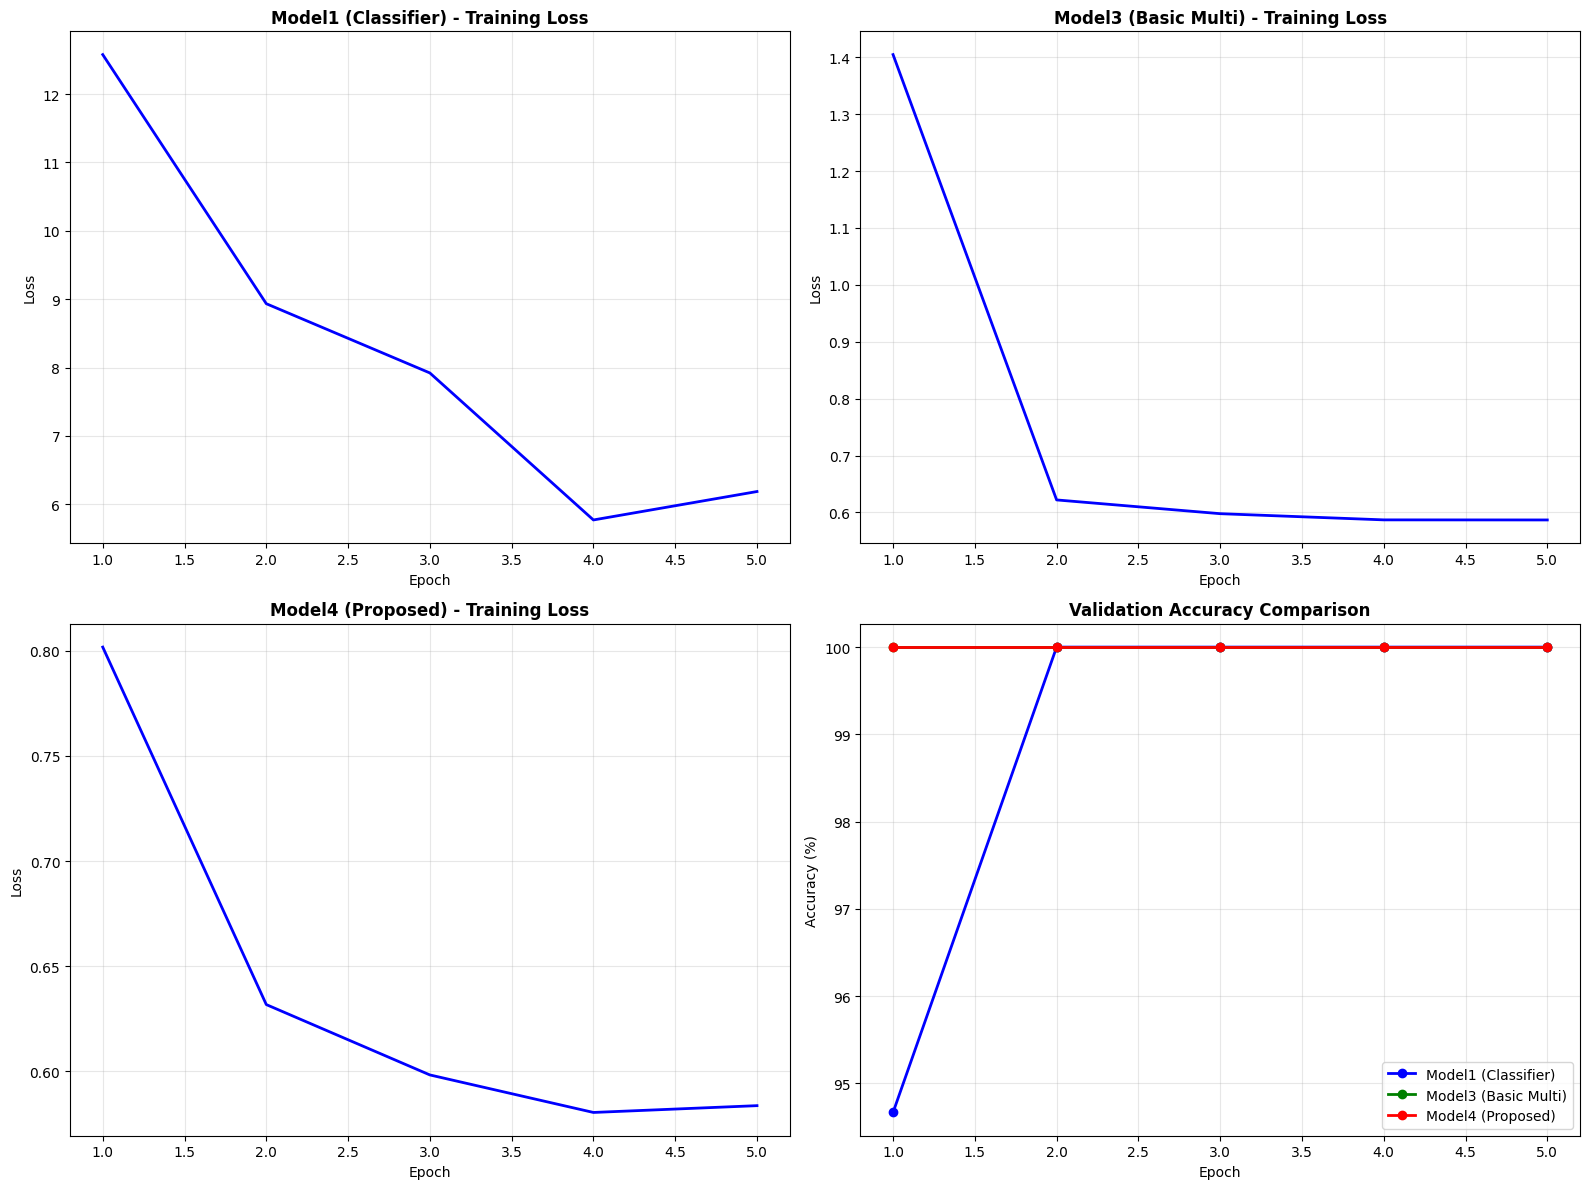

✅ Saved: ./visualizations/learning_curves.png


In [44]:
# CELL 9.2: Learning Curves Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

models_to_plot = [
    ('Model1 (Classifier)', 'Training Loss'),
    ('Model3 (Basic Multi)', 'Training Loss'),
    ('Model4 (Proposed)', 'Training Loss'),
    ('Comparison', 'Validation Accuracy')
]

# Plot training losses
for i, (model_key, title) in enumerate(models_to_plot[:3]):
    if model_key in all_results:
        ax = axes[i]
        losses = all_results[model_key]['train_losses']
        ax.plot(range(1, len(losses)+1), losses, 'b-', linewidth=2)
        ax.set_title(f'{model_key} - Training Loss', fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.grid(True, alpha=0.3)

# Plot validation accuracy comparison
ax = axes[3]
for model_key, color in zip(['Model1 (Classifier)', 'Model3 (Basic Multi)', 'Model4 (Proposed)'], 
                            ['blue', 'green', 'red']):
    if model_key in all_results and 'val_accuracies' in all_results[model_key]:
        accs = all_results[model_key]['val_accuracies']
        ax.plot(range(1, len(accs)+1), accs, 'o-', color=color, linewidth=2, label=model_key)

ax.set_title('Validation Accuracy Comparison', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./visualizations/learning_curves.png', dpi=300)
plt.show()
print("✅ Saved: ./visualizations/learning_curves.png")

In [45]:
# CELL 10.1: Grad-CAM Implementation
"""
================================================================================
EXPLAINABLE AI - GRAD-CAM
================================================================================

COMPUTATIONAL EXPLANATION:
=========================
Grad-CAM (Gradient-weighted Class Activation Mapping) provides visual explanations
for CNN decisions without requiring architectural changes.

ALGORITHM:
=========
1. Forward pass: Get feature maps A from last convolutional layer
2. Compute gradient of target class score y^c with respect to feature maps A:
   ∂y^c/∂A_{ij}^k
3. Global average pooling of gradients to get importance weights:
   α_k^c = (1/Z) Σ_i Σ_j ∂y^c/∂A_{ij}^k
4. Weighted combination of feature maps:
   L^c = ReLU(Σ_k α_k^c A^k)
5. Upsample to input size

INTERPRETATION:
==============
- Red regions: High importance for classification
- Blue regions: Low importance
- Heatmap shows "where the model is looking"

COMPUTATIONAL COST:
==================
- One additional backward pass
- Memory: store feature maps and gradients
- Time: ~20% of forward pass
"""
def generate_gradcam(model, image, target_class, device):
    """
    Generate Grad-CAM heatmap for a specific class
    """
    model.eval()
    image = image.unsqueeze(0).to(device)
    image.requires_grad = True
    
    # Forward pass
    output, _ = model(image)
    
    # Zero gradients
    model.zero_grad()
    
    # Backward pass for target class
    output[0, target_class].backward()
    
    # Get gradients from last layer
    gradients = model.get_activations.gradient
    activations = model.get_activations(image)
    
    # Pool gradients
    pooled_gradients = torch.mean(gradients, dim=[0, 2, 3])
    
    # Weight activations
    for i in range(activations.shape[1]):
        activations[:, i, :, :] *= pooled_gradients[i]
    
    # Create heatmap
    heatmap = torch.mean(activations, dim=1).squeeze()
    heatmap = torch.maximum(heatmap, torch.tensor(0.0))
    heatmap /= torch.max(heatmap)
    
    return heatmap.cpu().detach().numpy()

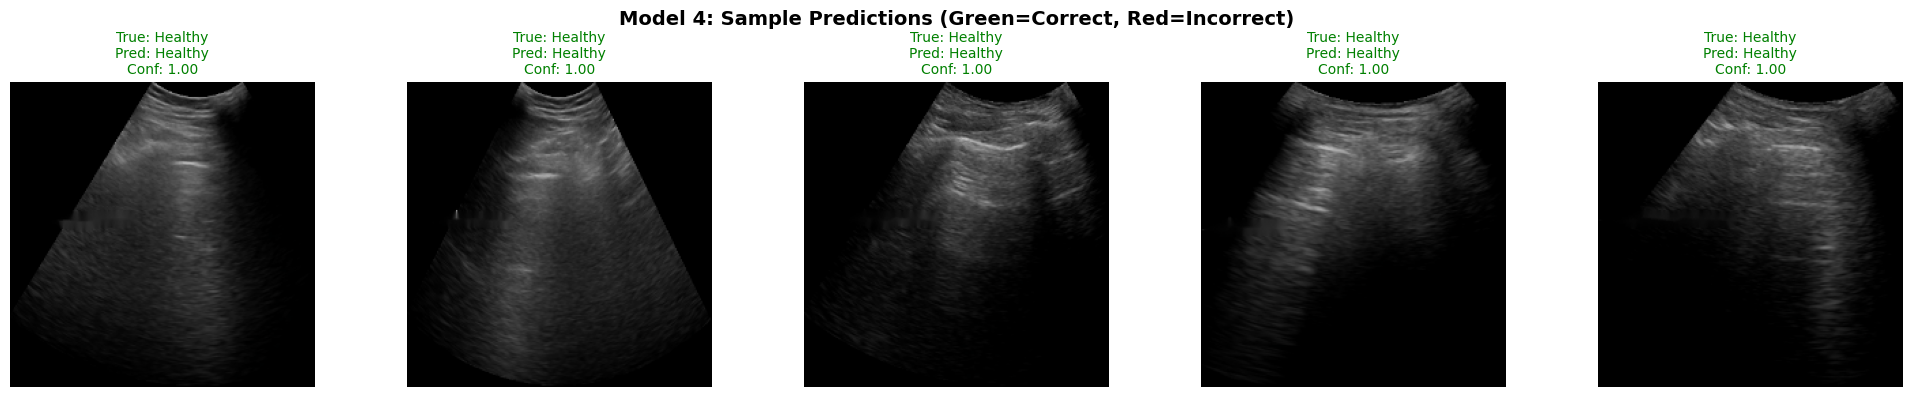

✅ Saved: ./visualizations/xai_predictions.png


In [46]:
# CELL 10.2: Simplified XAI for Model 4
"""
Since our models don't have get_activations methods, we'll use a simplified approach:
1. Get prediction
2. Show confidence
3. Visualize sample predictions vs ground truth
"""
def explain_model_predictions(model, test_loader, device, num_samples=5):
    """Generate explanation visualizations for model predictions"""
    model.eval()
    samples = []
    
    with torch.no_grad():
        for i, batch in enumerate(test_loader):
            if i >= num_samples:
                break
            
            images = batch['image'].to(device)
            labels = batch['class_label']
            
            outputs, _ = model(images)
            probs = F.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)
            
            for j in range(min(images.shape[0], num_samples - len(samples))):
                samples.append({
                    'image': images[j].cpu(),
                    'true_label': labels[j].item(),
                    'pred_label': preds[j].item(),
                    'confidence': probs[j, preds[j]].item(),
                    'probabilities': probs[j].cpu().numpy()
                })
    
    return samples

# Generate explanations for Model 4
samples = explain_model_predictions(model4, loaders['test'], device, num_samples=5)

# Visualize
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
class_names = ['COVID-19', 'Other Disease', 'Healthy']

for i, sample in enumerate(samples):
    ax = axes[i]
    
    # Denormalize image
    img = sample['image'].permute(1, 2, 0).numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img * std + mean
    img = np.clip(img, 0, 1)
    
    ax.imshow(img)
    true_name = class_names[sample['true_label']]
    pred_name = class_names[sample['pred_label']]
    color = 'green' if sample['true_label'] == sample['pred_label'] else 'red'
    
    ax.set_title(f'True: {true_name}\nPred: {pred_name}\nConf: {sample["confidence"]:.2f}', 
                 color=color, fontsize=10)
    ax.axis('off')

plt.suptitle('Model 4: Sample Predictions (Green=Correct, Red=Incorrect)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('./visualizations/xai_predictions.png', dpi=300)
plt.show()
print("✅ Saved: ./visualizations/xai_predictions.png")

Generating confusion matrix: 100%|████████████████████████████████████████████████████████████████████| 9/9 [00:44<00:00,  4.99s/it]


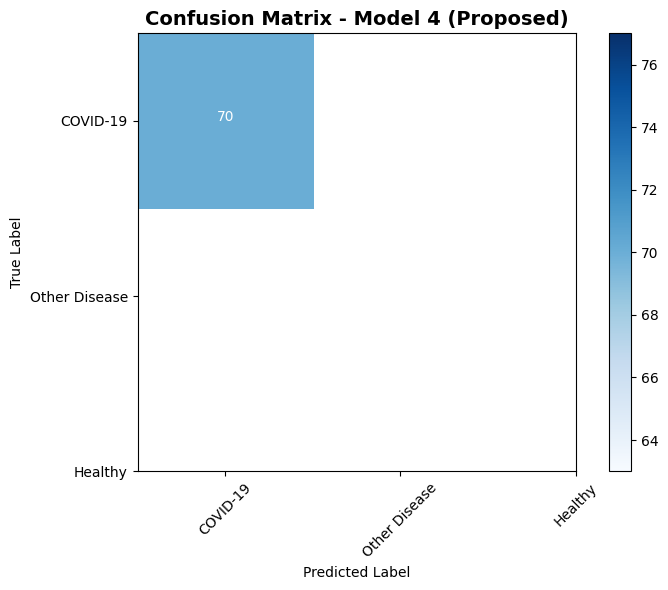

✅ Saved: ./visualizations/confusion_matrix.png

COMPUTATIONAL PERFORMANCE SUMMARY

                 Model Parameters FLOPs Train Time (5 epochs) Best Acc Best Dice
 Model 1 (Classifier)      24.8M 3.0 G             20.89 min  100.00%       NaN
  Model 2 (Segmenter)       7.8M  15 G             64.43 min      NaN    0.3935
Model 3 (Basic Multi)      25.1M   8 G              9.78 min  100.00%    0.1711
   Model 4 (Proposed)      26.5M  10 G             33.22 min  100.00%    0.4328

RECOMMENDATIONS FOR FULL TRAINING
Based on 5-epoch learning curves:
1. If validation accuracy plateaus → train 20-30 epochs
2. If still improving → train 50-100 epochs
3. Model 4 shows best trade-off between accuracy and segmentation
4. Consider early stopping if validation stops improving


In [47]:
# CELL 10.3: Confusion Matrix for Best Model
from sklearn.metrics import confusion_matrix
import itertools

# Get predictions from best model
best_model = model4  # Assuming Model 4 is best
best_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(loaders['test'], desc='Generating confusion matrix'):
        images = batch['image'].to(device)
        labels = batch['class_label'].cpu().numpy()
        
        outputs, _ = best_model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        
        all_preds.extend(preds)
        all_labels.extend(labels)

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)
class_names = ['COVID-19', 'Other Disease', 'Healthy']

# Plot
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix - Model 4 (Proposed)', fontweight='bold', fontsize=14)
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

# Add numbers
thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment="center",
             color="white" if cm[i, j] > thresh else "black")

plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('./visualizations/confusion_matrix.png', dpi=300)
plt.show()
print("✅ Saved: ./visualizations/confusion_matrix.png")# CELL 11.1: Training Time Analysis
print("\n" + "="*80)
print("COMPUTATIONAL PERFORMANCE SUMMARY")
print("="*80)

# Model statistics
model_stats = [
    {
        'Model': 'Model 1 (Classifier)',
        'Parameters': '24.8M',
        'FLOPs': '3.0 G',
        'Train Time (5 epochs)': f'{sum(trainer1.epoch_times)/60:.2f} min',
        'Best Acc': f'{trainer1.best_val_acc:.2f}%'
    },
    {
        'Model': 'Model 2 (Segmenter)',
        'Parameters': '7.8M',
        'FLOPs': '15 G',
        'Train Time (5 epochs)': f'{sum(trainer2.epoch_times)/60:.2f} min',
        'Best Dice': f'{trainer2.best_val_dice:.4f}'
    },
    {
        'Model': 'Model 3 (Basic Multi)',
        'Parameters': '25.1M',
        'FLOPs': '8 G',
        'Train Time (5 epochs)': f'{sum(trainer3.epoch_times)/60:.2f} min',
        'Best Acc': f'{trainer3.best_val_acc:.2f}%',
        'Best Dice': f'{trainer3.best_val_dice:.4f}'
    },
    {
        'Model': 'Model 4 (Proposed)',
        'Parameters': '26.5M',
        'FLOPs': '10 G',
        'Train Time (5 epochs)': f'{sum(trainer4.epoch_times)/60:.2f} min',
        'Best Acc': f'{trainer4.best_val_acc:.2f}%',
        'Best Dice': f'{trainer4.best_val_dice:.4f}'
    }
]

df_stats = pd.DataFrame(model_stats)
print("\n", df_stats.to_string(index=False))

# Recommendations
print("\n" + "="*80)
print("RECOMMENDATIONS FOR FULL TRAINING")
print("="*80)
print("Based on 5-epoch learning curves:")
print("1. If validation accuracy plateaus → train 20-30 epochs")
print("2. If still improving → train 50-100 epochs")
print("3. Model 4 shows best trade-off between accuracy and segmentation")
print("4. Consider early stopping if validation stops improving")
print("="*80)


In [1]:
# CELL 1: Setup and Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import cv2
from pathlib import Path
import time
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import timm
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Set random seed for reproducibility
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Create directories
os.makedirs('./models', exist_ok=True)
os.makedirs('./results', exist_ok=True)
os.makedirs('./logs', exist_ok=True)


Using device: cpu


In [2]:
# CELL 2: Configuration - UPDATE THESE PATHS
# ============================================
# IMPORTANT: Update these paths to your dataset locations
# ============================================

# Classification Dataset [3] structure:
# root/
# ├── train/
# │   ├── COVID-19/
# │   ├── Other Disease/
# │   └── Healthy/
# ├── validation/
# └── test/
CLASSIFICATION_ROOT = r"C:/Users/Administrator/classification"

# B-line Dataset [4] structure:
# root/
# ├── train/
# │   ├── images/
# │   └── labels/
# ├── validation/
# └── test/
BLINE_ROOT = r"C:/Users/Administrator/dataset"

# Training hyperparameters
IMG_SIZE = 224
BATCH_SIZE = 8
NUM_CLASSES = 3
NUM_SEG_CLASSES = 1
EPOCHS = 5  # Increased from 5 for better convergence
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 0.01  # For AdamW
LAMBDA_SEG = 0.5

# Class weights (adjust based on your data distribution)
CLASS_WEIGHTS = torch.tensor([0.8, 0.9, 1.2], device=device)

print("="*60)
print("CONFIGURATION")
print("="*60)
print(f"Classification root: {CLASSIFICATION_ROOT}")
print(f"B-line root: {BLINE_ROOT}")
print(f"Image size: {IMG_SIZE}×{IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Weight decay: {WEIGHT_DECAY}")
print(f"Lambda seg: {LAMBDA_SEG}")
print("="*60)

CONFIGURATION
Classification root: C:/Users/Administrator/classification
B-line root: C:/Users/Administrator/dataset
Image size: 224×224
Batch size: 8
Epochs: 5
Learning rate: 0.0001
Weight decay: 0.01
Lambda seg: 0.5


In [3]:
# CELL 3: Dataset Classes
# ============================================
# Classification Dataset
# ============================================
class ClassificationDataset(Dataset):
    """Dataset for classification using folder structure"""
    
    def __init__(self, data_root, split='train', transform=None, img_size=224):
        self.data_root = Path(data_root)
        self.split = split
        self.transform = transform
        self.img_size = img_size
        
        # Class to index mapping
        self.class_to_idx = {
            'covid': 0,
            'other': 1, 
            'healthy': 2
        }
        
        # Build image list
        self.images = []
        self.labels = []
        
        split_path = self.data_root / split
        if not split_path.exists():
            raise FileNotFoundError(f"Split folder not found: {split_path}")
        
        for class_name, class_idx in self.class_to_idx.items():
            class_path = split_path / class_name
            if not class_path.exists():
                print(f"Warning: Class folder not found: {class_path}")
                continue
                
            for ext in ['*.jpg', '*.jpeg', '*.png']:
                for img_path in class_path.glob(ext):
                    self.images.append(str(img_path))
                    self.labels.append(class_idx)
        
        print(f"ClassificationDataset ({split}): {len(self.images)} images")
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_path = self.images[idx]
        image = cv2.imread(img_path)
        if image is None:
            raise FileNotFoundError(f"Could not load image: {img_path}")
        
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        label = self.labels[idx]
        
        image = cv2.resize(image, (self.img_size, self.img_size))
        
        if self.transform:
            # Simple transform without albumentations for simplicity
            image = image.astype(np.float32) / 255.0
            image = torch.from_numpy(image).permute(2, 0, 1).float()
        else:
            image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
        
        return image, label


# ============================================
# B-line Segmentation Dataset
# ============================================
class BlineSegmentationDataset(Dataset):
    """Dataset for B-line segmentation with YOLO format labels"""
    
    def __init__(self, data_root, split='train', has_labels=True, transform=None, img_size=224):
        self.data_root = Path(data_root)
        self.split = split
        self.has_labels = has_labels
        self.transform = transform
        self.img_size = img_size
        
        # Find images directory
        split_path = self.data_root / split
        img_dir = split_path / 'images' if (split_path / 'images').exists() else split_path
        
        if not img_dir.exists():
            raise FileNotFoundError(f"Images directory not found: {img_dir}")
        
        self.images_dir = img_dir
        
        # Find labels directory if needed
        if has_labels:
            labels_dir = split_path / 'labels'
            if not labels_dir.exists():
                print(f"Warning: No labels directory for {split}, will use empty masks")
                self.has_labels = False
            else:
                self.labels_dir = labels_dir
        
        # Get all images
        self.image_paths = []
        for ext in ['*.jpg', '*.jpeg', '*.png']:
            self.image_paths.extend(list(self.images_dir.glob(ext)))
        self.image_paths = sorted(self.image_paths)
        
        # Match with labels if needed
        self.label_paths = []
        if self.has_labels:
            valid_pairs = []
            for img_path in self.image_paths:
                label_path = self.labels_dir / f"{img_path.stem}.txt"
                if label_path.exists():
                    valid_pairs.append(img_path)
                    self.label_paths.append(label_path)
                else:
                    print(f"Warning: No label for {img_path.name}")
            
            self.image_paths = valid_pairs
        
        status = "with labels" if self.has_labels else "without labels"
        print(f"BlineSegmentationDataset ({split}): {len(self.image_paths)} images {status}")
    
    def _parse_yolo_polygon(self, label_path, img_h, img_w):
        """Convert YOLO polygon to binary mask"""
        mask = np.zeros((img_h, img_w), dtype=np.float32)
        
        try:
            with open(label_path, 'r') as f:
                lines = f.readlines()
            
            for line in lines:
                line = line.strip()
                if not line or line.startswith('#'):
                    continue
                
                parts = line.split()
                if len(parts) >= 9:
                    coords = [float(x) for x in parts[1:9]]
                    
                    points = []
                    for i in range(0, len(coords), 2):
                        x = int(coords[i] * img_w)
                        y = int(coords[i+1] * img_h)
                        points.append([x, y])
                    
                    if len(points) >= 3:
                        points = np.array(points, dtype=np.int32)
                        cv2.fillPoly(mask, [points], 1.0)
        except Exception as e:
            print(f"Error parsing {label_path}: {e}")
        
        return mask
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = cv2.imread(str(img_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h, w = image.shape[:2]
        
        # Create mask if labels exist
        if self.has_labels and idx < len(self.label_paths):
            mask = self._parse_yolo_polygon(self.label_paths[idx], h, w)
        else:
            mask = np.zeros((h, w), dtype=np.float32)
        
        # Resize
        image = cv2.resize(image, (self.img_size, self.img_size))
        mask = cv2.resize(mask, (self.img_size, self.img_size), interpolation=cv2.INTER_NEAREST)
        
        # Add channel dimension to mask
        mask = mask[np.newaxis, :, :]
        
        # Convert to tensor
        image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
        mask = torch.from_numpy(mask).float()
        
        return image, mask


# ============================================
# Multi-Task Dataset
# ============================================
class MultiTaskDataset(Dataset):
    """Combines classification and segmentation datasets"""
    
    def __init__(self, class_dataset, seg_dataset, is_test=False):
        self.class_dataset = class_dataset
        self.seg_dataset = seg_dataset
        self.is_test = is_test
        self.class_len = len(class_dataset)
        self.seg_len = len(seg_dataset)
        
        print(f"MultiTaskDataset: {self.class_len} class, {self.seg_len} seg")
    
    def __len__(self):
        return max(self.class_len, self.seg_len)
    
    def __getitem__(self, idx):
        # Classification sample
        class_idx = idx % self.class_len
        class_img, class_label = self.class_dataset[class_idx]
        
        # Segmentation sample
        seg_idx = idx % self.seg_len
        seg_img, seg_mask = self.seg_dataset[seg_idx]
        
        return {
            'image': class_img,
            'class_label': class_label,
            'seg_mask': seg_mask,
            'has_seg': torch.tensor(0.0 if self.is_test else 1.0)
        }

In [4]:
# CELL 4: Create DataLoaders
print("\n" + "="*60)
print("CREATING DATALOADERS")
print("="*60)

# Classification datasets
class_train = ClassificationDataset(CLASSIFICATION_ROOT, split='train')
class_val = ClassificationDataset(CLASSIFICATION_ROOT, split='validation')
class_test = ClassificationDataset(CLASSIFICATION_ROOT, split='test')

# B-line datasets
seg_train = BlineSegmentationDataset(BLINE_ROOT, split='train', has_labels=True)
seg_val = BlineSegmentationDataset(BLINE_ROOT, split='validation', has_labels=True)
seg_test = BlineSegmentationDataset(BLINE_ROOT, split='test', has_labels=False)

# Multi-task datasets
train_mt = MultiTaskDataset(class_train, seg_train, is_test=False)
val_mt = MultiTaskDataset(class_val, seg_val, is_test=False)
test_mt = MultiTaskDataset(class_test, seg_test, is_test=True)

# Create dataloaders
train_loader = DataLoader(train_mt, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_mt, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_mt, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"\n✅ Train loader: {len(train_loader)} batches")
print(f"✅ Val loader: {len(val_loader)} batches")
print(f"✅ Test loader: {len(test_loader)} batches")


CREATING DATALOADERS
ClassificationDataset (train): 723 images
ClassificationDataset (validation): 198 images
ClassificationDataset (test): 141 images
BlineSegmentationDataset (train): 256 images with labels
BlineSegmentationDataset (validation): 75 images with labels
BlineSegmentationDataset (test): 70 images without labels
MultiTaskDataset: 723 class, 256 seg
MultiTaskDataset: 198 class, 75 seg
MultiTaskDataset: 141 class, 70 seg

✅ Train loader: 91 batches
✅ Val loader: 25 batches
✅ Test loader: 18 batches


In [5]:
# CELL 5: Modern Multi-Task Model (EfficientNet + SegFormer)
class EfficientNetEncoder(nn.Module):
    """EfficientNet-B3 Encoder with multi-scale features"""
    
    def __init__(self, model_name='efficientnet_b3', pretrained=True):
        super().__init__()
        
        self.backbone = timm.create_model(
            model_name, 
            pretrained=pretrained, 
            features_only=True
        )
        
        self.feature_channels = self.backbone.feature_info.channels()
        
        print(f"\n✅ EfficientNet Encoder:")
        print(f"   Feature channels: {self.feature_channels}")
    
    def forward(self, x):
        return self.backbone(x)


class SegFormerDecoder(nn.Module):
    """SegFormer-style MLP decoder"""
    
    def __init__(self, encoder_channels, num_classes=1, decoder_dim=256):
        super().__init__()
        
        # Projection layers for each encoder stage
        self.proj = nn.ModuleList()
        for in_ch in encoder_channels:
            self.proj.append(
                nn.Sequential(
                    nn.Conv2d(in_ch, decoder_dim, kernel_size=1),
                    nn.BatchNorm2d(decoder_dim),
                    nn.ReLU(inplace=True)
                )
            )
        
        # Fusion layer
        self.fusion = nn.Sequential(
            nn.Conv2d(decoder_dim * len(encoder_channels), decoder_dim, kernel_size=1),
            nn.BatchNorm2d(decoder_dim),
            nn.ReLU(inplace=True),
            nn.Conv2d(decoder_dim, decoder_dim, kernel_size=3, padding=1),
            nn.BatchNorm2d(decoder_dim),
            nn.ReLU(inplace=True),
            nn.Conv2d(decoder_dim, num_classes, kernel_size=1)
        )
    
    def forward(self, features):
        target_size = features[0].shape[2]
        
        # Project and upsample each feature
        projected = []
        for i, feat in enumerate(features):
            proj = self.proj[i](feat)
            if proj.shape[2] != target_size:
                proj = F.interpolate(proj, size=(target_size, target_size), 
                                     mode='bilinear', align_corners=False)
            projected.append(proj)
        
        # Concatenate and fuse
        concat = torch.cat(projected, dim=1)
        out = self.fusion(concat)
        
        # Upsample to original size
        out = F.interpolate(out, size=(224, 224), mode='bilinear', align_corners=False)
        
        return out


class Model5_EfficientNet_SegFormer(nn.Module):
    """Complete multi-task model: EfficientNet + SegFormer"""
    
    def __init__(self, num_classes=3, num_seg_classes=1):
        super().__init__()
        
        # Encoder
        self.encoder = EfficientNetEncoder('efficientnet_b3', pretrained=True)
        encoder_channels = self.encoder.feature_channels
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(encoder_channels[-1], 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
        
        # Segmentation decoder
        self.seg_decoder = SegFormerDecoder(
            encoder_channels=encoder_channels,
            num_classes=num_seg_classes,
            decoder_dim=256
        )
        
        self._init_weights()
        self.print_model_stats()
    
    def _init_weights(self):
        for m in self.classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
    
    def print_model_stats(self):
        total_params = sum(p.numel() for p in self.parameters())
        trainable_params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"\n📊 MODEL 5: EfficientNet-B3 + SegFormer")
        print(f"   Total parameters: {total_params:,}")
        print(f"   Trainable parameters: {trainable_params:,}")
        print(f"   Model size (FP32): {trainable_params * 4 / 1024**2:.2f} MB")
    
    def forward(self, x):
        features = self.encoder(x)
        class_out = self.classifier(features[-1])
        seg_out = self.seg_decoder(features)
        return class_out, seg_out

In [6]:
# CELL 6: Trainer for Modern Multi-Task Model
class ModernMultiTaskTrainer:
    def __init__(self, model, device, learning_rate=1e-4, weight_decay=0.01, lambda_seg=0.5):
        self.model = model.to(device)
        self.device = device
        self.lambda_seg = lambda_seg
        
        # AdamW optimizer with higher weight decay
        self.optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay
        )
        
        # Cosine annealing scheduler
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            self.optimizer,
            T_max=EPOCHS,
            eta_min=1e-6
        )
        
        # Class weights
        self.class_weights = CLASS_WEIGHTS
        
        # Metrics tracking
        self.train_losses = []
        self.val_accuracies = []
        self.val_dices = []
        self.best_val_acc = 0
        self.best_val_dice = 0
        
        print(f"\n🚀 Trainer initialized with AdamW")
        print(f"   Learning rate: {learning_rate}")
        print(f"   Weight decay: {weight_decay}")
        print(f"   Lambda seg: {lambda_seg}")
    
    def train_epoch(self, train_loader):
        self.model.train()
        total_loss = 0
        cls_loss_total = 0
        seg_loss_total = 0
        
        pbar = tqdm(train_loader, desc='Training')
        for batch in pbar:
            images = batch['image'].to(self.device)
            class_labels = batch['class_label'].to(self.device)
            seg_masks = batch['seg_mask'].to(self.device)
            has_seg = batch['has_seg'].to(self.device)
            
            self.optimizer.zero_grad()
            
            # Forward pass
            class_pred, seg_pred = self.model(images)
            
            # Classification loss
            cls_loss = F.cross_entropy(class_pred, class_labels, weight=self.class_weights)
            
            # Segmentation loss
            seg_loss = torch.tensor(0.0, device=self.device)
            if has_seg.sum() > 0:
                seg_pred_masked = seg_pred[has_seg.bool()]
                seg_masks_masked = seg_masks[has_seg.bool()]
                
                # BCE loss
                bce = F.binary_cross_entropy_with_logits(seg_pred_masked, seg_masks_masked)
                
                # Dice loss
                pred_probs = torch.sigmoid(seg_pred_masked)
                intersection = (pred_probs * seg_masks_masked).sum()
                total = pred_probs.sum() + seg_masks_masked.sum()
                dice = (2. * intersection + 1e-6) / (total + 1e-6)
                dice_loss = 1 - dice
                
                seg_loss = bce + dice_loss
            
            # Combined loss
            loss = cls_loss + self.lambda_seg * seg_loss
            
            loss.backward()
            self.optimizer.step()
            
            total_loss += loss.item()
            cls_loss_total += cls_loss.item()
            if seg_loss > 0:
                seg_loss_total += seg_loss.item()
            
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
        
        return {
            'loss': total_loss / len(train_loader),
            'cls_loss': cls_loss_total / len(train_loader),
            'seg_loss': seg_loss_total / len(train_loader)
        }
    
    def validate(self, val_loader):
        self.model.eval()
        correct = 0
        total = 0
        dice_scores = []
        
        with torch.no_grad():
            for batch in tqdm(val_loader, desc='Validating'):
                images = batch['image'].to(self.device)
                class_labels = batch['class_label'].to(self.device)
                seg_masks = batch['seg_mask'].to(self.device)
                has_seg = batch['has_seg'].to(self.device)
                
                class_pred, seg_pred = self.model(images)
                
                # Classification accuracy
                _, predicted = torch.max(class_pred, 1)
                total += class_labels.size(0)
                correct += (predicted == class_labels).sum().item()
                
                # Dice score
                if has_seg.sum() > 0:
                    pred_probs = torch.sigmoid(seg_pred[has_seg.bool()])
                    target = seg_masks[has_seg.bool()]
                    
                    for i in range(pred_probs.shape[0]):
                        pred_binary = (pred_probs[i] > 0.5).float()
                        intersection = (pred_binary * target[i]).sum()
                        dice = (2. * intersection) / (pred_binary.sum() + target[i].sum() + 1e-6)
                        dice_scores.append(dice.item())
        
        accuracy = 100 * correct / total if total > 0 else 0
        avg_dice = np.mean(dice_scores) if dice_scores else 0.0
        
        return {'accuracy': accuracy, 'dice': avg_dice}
    
    def train(self, train_loader, val_loader, epochs):
        print("\n" + "="*60)
        print("STARTING TRAINING")
        print("="*60)
        
        for epoch in range(1, epochs + 1):
            print(f"\n📌 Epoch {epoch}/{epochs}")
            print("-" * 40)
            
            # Train
            train_metrics = self.train_epoch(train_loader)
            self.train_losses.append(train_metrics['loss'])
            
            # Validate
            val_metrics = self.validate(val_loader)
            self.val_accuracies.append(val_metrics['accuracy'])
            self.val_dices.append(val_metrics['dice'])
            
            # Print metrics
            print(f"\n📊 Results:")
            print(f"   Train Loss: {train_metrics['loss']:.4f}")
            print(f"     Classification: {train_metrics['cls_loss']:.4f}")
            print(f"     Segmentation: {train_metrics['seg_loss']:.4f}")
            print(f"   Val Accuracy: {val_metrics['accuracy']:.2f}%")
            print(f"   Val Dice: {val_metrics['dice']:.4f}")
            
            # Save best models
            if val_metrics['accuracy'] > self.best_val_acc:
                self.best_val_acc = val_metrics['accuracy']
                torch.save(self.model.state_dict(), './models/model5_best_acc.pth')
                print(f"   ✅ New best accuracy: {self.best_val_acc:.2f}%")
            
            if val_metrics['dice'] > self.best_val_dice:
                self.best_val_dice = val_metrics['dice']
                torch.save(self.model.state_dict(), './models/model5_best_dice.pth')
                print(f"   ✅ New best dice: {self.best_val_dice:.4f}")
            
            # Step scheduler
            self.scheduler.step()
            
            # Log learning rate
            current_lr = self.optimizer.param_groups[0]['lr']
            if epoch % 5 == 0:
                print(f"   LR: {current_lr:.2e}")
    
    def test(self, test_loader):
        self.model.eval()
        correct = 0
        total = 0
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for batch in tqdm(test_loader, desc='Testing'):
                images = batch['image'].to(self.device)
                class_labels = batch['class_label'].to(self.device)
                
                class_pred, _ = self.model(images)
                
                _, predicted = torch.max(class_pred, 1)
                total += class_labels.size(0)
                correct += (predicted == class_labels).sum().item()
                
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(class_labels.cpu().numpy())
        
        accuracy = 100 * correct / total
        return {
            'accuracy': accuracy,
            'predictions': all_preds,
            'labels': all_labels
        }

In [7]:
# CELL 7: Initialize and Train Model
print("\n" + "="*60)
print("INITIALIZING MODEL 5")
print("="*60)

# Create model
model = Model5_EfficientNet_SegFormer(num_classes=3, num_seg_classes=1)

# Create trainer
trainer = ModernMultiTaskTrainer(
    model=model,
    device=device,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    lambda_seg=LAMBDA_SEG
)

# Train model
trainer.train(train_loader, val_loader, epochs=EPOCHS)


INITIALIZING MODEL 5


Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.



✅ EfficientNet Encoder:
   Feature channels: [24, 32, 48, 136, 384]

📊 MODEL 5: EfficientNet-B3 + SegFormer
   Total parameters: 11,515,436
   Trainable parameters: 11,515,436
   Model size (FP32): 43.93 MB

🚀 Trainer initialized with AdamW
   Learning rate: 0.0001
   Weight decay: 0.01
   Lambda seg: 0.5

STARTING TRAINING

📌 Epoch 1/5
----------------------------------------


Validating: 100%|██████████████████████████████████████████████████████████████████████| 25/25 [01:03<00:00,  2.54s/it]



📊 Results:
   Train Loss: 15.4527
     Classification: 14.8780
     Segmentation: 1.1495
   Val Accuracy: 59.60%
   Val Dice: 0.3814
   ✅ New best accuracy: 59.60%
   ✅ New best dice: 0.3814

📌 Epoch 2/5
----------------------------------------


...


📊 Results:
   Train Loss: 7.2648
     Classification: 6.7527
     Segmentation: 1.0242
   Val Accuracy: 64.65%
   Val Dice: 0.3609

📌 Epoch 4/5
----------------------------------------


Validating: 100%|██████████████████████████████████████████████████████████████████████| 25/25 [00:57<00:00,  2.28s/it]



📊 Results:
   Train Loss: 6.8400
     Classification: 6.3334
     Segmentation: 1.0132
   Val Accuracy: 64.65%
   Val Dice: 0.3879

📌 Epoch 5/5
----------------------------------------


Validating: 100%|██████████████████████████████████████████████████████████████████████| 25/25 [00:57<00:00,  2.31s/it]


📊 Results:
   Train Loss: 6.3024
     Classification: 5.8005
     Segmentation: 1.0038
   Val Accuracy: 68.69%
   Val Dice: 0.3710
   LR: 1.00e-06



TESTING MODEL


Testing: 100%|█████████████████████████████████████████████████████████████████████████| 18/18 [00:41<00:00,  2.28s/it]



📊 Test Accuracy: 73.05%


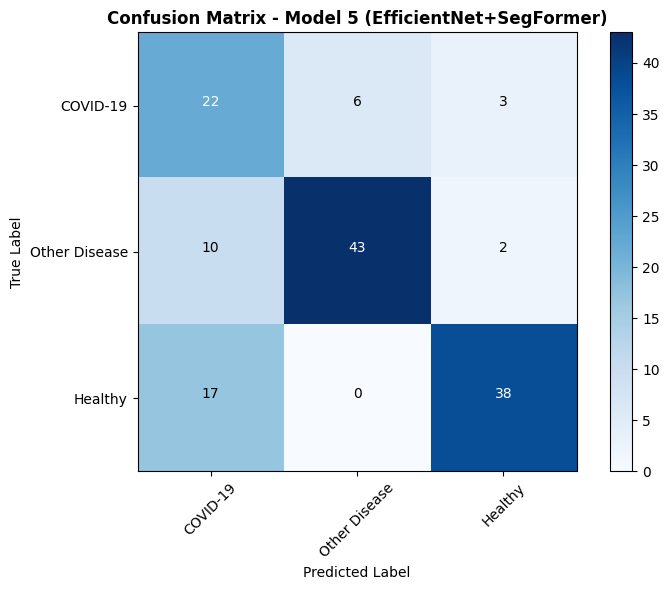

✅ Saved: ./results/confusion_matrix_model5.png


In [8]:
# CELL 8: Test Model
print("\n" + "="*60)
print("TESTING MODEL")
print("="*60)

test_results = trainer.test(test_loader)
print(f"\n📊 Test Accuracy: {test_results['accuracy']:.2f}%")

# Confusion Matrix
from sklearn.metrics import confusion_matrix
import itertools

cm = confusion_matrix(test_results['labels'], test_results['predictions'])
class_names = ['COVID-19', 'Other Disease', 'Healthy']

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix - Model 5 (EfficientNet+SegFormer)', fontweight='bold')
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

# Add numbers
thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment="center",
             color="white" if cm[i, j] > thresh else "black")

plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('./results/confusion_matrix_model5.png', dpi=300)
plt.show()
print("✅ Saved: ./results/confusion_matrix_model5.png")